# MGMT 590 -- LendingClub Loan Default Risk (Indiana Borrowers)
## Phase 2: Exploratory Data Analysis & Statistical Foundation

**Course:** MGMT 59000, Summer 2026, Section DY2 -- Purdue University
**Builds on:** Phase 1 (`src/config.py`, `src/utils.py`, `src/train_models.py`,
the cleaned dataset, and the leakage-safe train/validation/test split).
**New in Phase 2:** `src/eda_utils.py` -- reusable plotting, descriptive-statistics,
and statistical-testing functions used throughout this notebook.

### Research questions this notebook supports

1. Which borrower characteristics appear associated with default?
2. Do LendingClub grades appear predictive?
3. Which variables appear related to higher interest rates?
4. Does income appear associated with repayment success?
5. Does DTI (debt-to-income) influence default?
6. Does employment length matter?
7. Can natural borrower groups already be observed before clustering?

### Scope note
This notebook performs **no machine learning** -- model training begins in
Phase 3. Every visualization and test here exists to inform which
features, transformations, and engineered variables Phase 3 should use.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config, utils, eda_utils

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)


def summarize(title: str, discovery: str, why_it_matters: str, action: str, question: str = ""):
    """Render a consistent 'Executive Summary' callout after each major section."""
    q_line = f"\n\n**Research question addressed:** {question}" if question else ""
    display(Markdown(
        f"> **Executive Summary -- {title}**\n>\n"
        f"> **What we found:** {discovery}\n>\n"
        f"> **Why it matters:** {why_it_matters}\n>\n"
        f"> **How LendingClub should use this:** {action}{q_line}"
    ))


In [2]:
# Load the Phase 1 cleaned dataset directly -- this notebook does NOT
# re-run ingestion/cleaning; it reuses Phase 1's output unmodified.
df = utils.load_dataframe(config.CLEANED_DATA_PATH)
print(f"Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


2026-07-29 14:08:02 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/processed/lendingclub_indiana_cleaned.csv — shape=(1500, 22)


Loaded cleaned dataset: 1,500 rows x 22 columns


,loan_amnt,term,int_rate,installment,grade,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,emp_length_years,default_flag
0,33815,36 months,8.15,1107.18,B,RENT,31051.48,Source Verified,major_purchase,9.02,1,6,0,39271,33.3,51,w,Individual,6,0,10.0,1
1,7597,60 months,11.38,126.32,E,OWN,37962.44,Verified,credit_card,14.53,1,2,0,59398,49.7,23,w,Individual,6,0,1.0,0
2,21693,36 months,10.45,1184.56,C,RENT,75928.07,Verified,credit_card,15.44,0,18,0,50455,72.8,39,f,Individual,6,0,2.0,0
3,37836,36 months,9.06,446.26,A,MORTGAGE,23044.16,Source Verified,other,17.38,0,14,0,8301,39.8,50,w,Individual,0,0,0.0,0
4,31764,60 months,13.14,1241.62,G,RENT,67139.39,Source Verified,credit_card,22.96,1,19,0,3910,44.5,25,f,Joint App,4,0,5.0,0


---
# 1. Dataset Overview

An executive summary of the analysis-ready dataset produced by Phase 1:
scope, structure, data quality, and target-variable balance.


In [3]:
overview = eda_utils.build_dataset_overview(df)

print(f"Observations: {overview.n_rows:,}")
print(f"Variables:    {overview.n_columns}")
print(f"Duplicate rows remaining: {overview.duplicate_row_count}")
print("\nColumns:")
print(overview.columns)


2026-07-29 14:08:02 | INFO     | src.eda_utils | Dataset overview built: 1500 rows, 22 cols, 0 duplicate rows, 2 cols with missing values.


Observations: 1,500
Variables:    22
Duplicate rows remaining: 0

Columns:
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'emp_length_years', 'default_flag']


In [4]:
var_table = eda_utils.variable_description_table(df)
var_table


,variable,dtype,description
0,loan_amnt,int64,Dollar amount of the loan requested by the bor...
1,term,str,Number of monthly payments (36 or 60 months).
2,int_rate,float64,Annual interest rate assigned to the loan (%).
3,installment,float64,Fixed monthly payment owed by the borrower ($).
4,grade,str,LendingClub-assigned risk grade (A = lowest ri...
5,home_ownership,str,Borrower's home ownership status (RENT/MORTGAG...
6,annual_inc,float64,Self-reported annual income ($).
7,verification_status,str,Whether income was verified by LendingClub.
8,purpose,str,Borrower-stated reason for the loan.
9,dti,float64,"Debt-to-income ratio, excluding mortgage, base..."


### Missing values

In [5]:
if overview.missing_summary.empty:
    print("No missing values remain in the cleaned dataset.")
else:
    display(overview.missing_summary)


,missing_count,missing_pct
emp_length_years,133,8.87
annual_inc,27,1.80


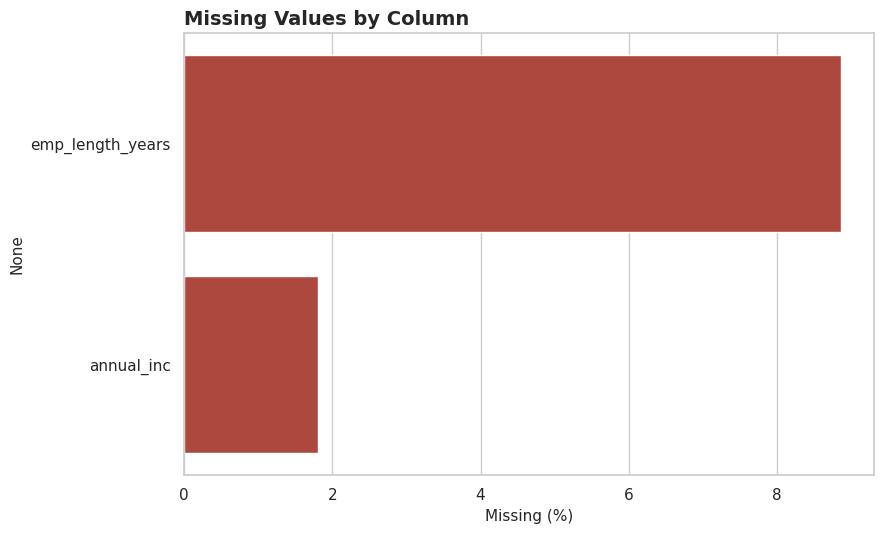

In [6]:
fig = eda_utils.plot_missing_value_bar(df, title="Missing Values by Column")
plt.show()


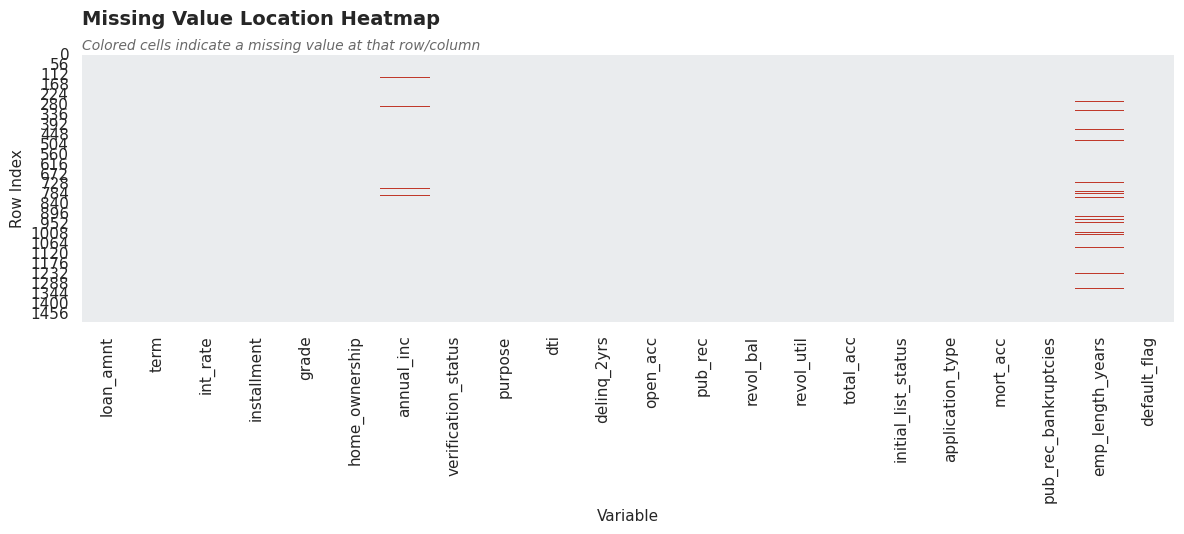

In [7]:
fig = eda_utils.plot_missing_value_heatmap(df, title="Missing Value Location Heatmap")
plt.show()


### Target variable balance (`default_flag`)

Recall from Phase 1: `default_flag = 1` for `Charged Off`/`Default` loans,
`0` for `Fully Paid` loans. Loans that had not reached a final resolution
(e.g. `Current`) were already excluded.


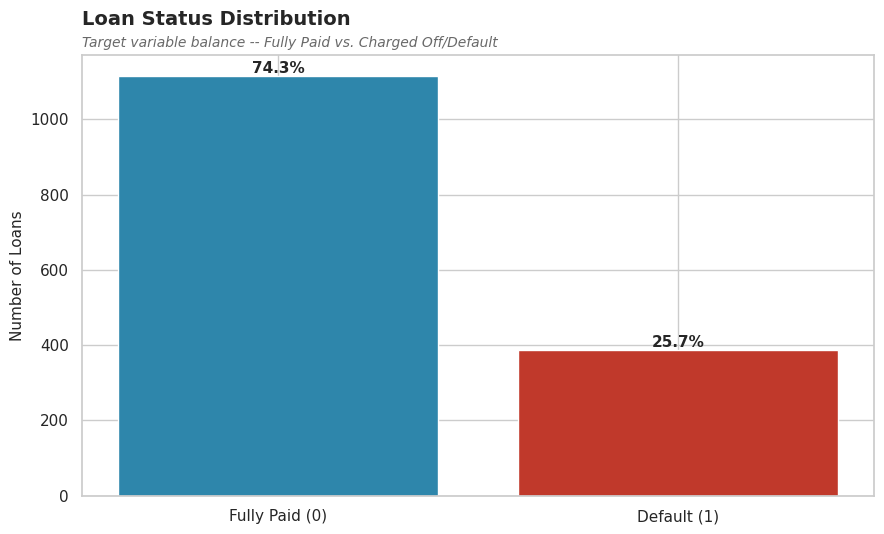

Default rate: 25.73%
Class imbalance ratio (majority:minority): 2.89 : 1


In [8]:
target_counts = df[config.TARGET_COLUMN].value_counts()
target_pct = df[config.TARGET_COLUMN].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=eda_utils.FIGSIZE_STANDARD)
bars = ax.bar(["Fully Paid (0)", "Default (1)"], target_counts.values,
              color=[eda_utils.COLOR_PAID, eda_utils.COLOR_DEFAULT])
for bar, pct in zip(bars, target_pct.reindex([0, 1]).values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{pct:.1%}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of Loans")
eda_utils._apply_titles(ax, "Loan Status Distribution",
                         "Target variable balance -- Fully Paid vs. Charged Off/Default")
fig.tight_layout()
plt.show()

print(f"Default rate: {target_pct[1]:.2%}")
print(f"Class imbalance ratio (majority:minority): {target_counts[0]/target_counts[1]:.2f} : 1")


**Class imbalance implications:** with roughly a 3:1 (or wider) ratio of
Fully Paid to Default loans, this is a moderately imbalanced
classification problem. A naive model that always predicts "Fully Paid"
would already achieve a deceptively high accuracy without identifying a
single risky borrower. This has direct consequences for Phase 3:

- **Accuracy alone will be a misleading metric.** Precision, recall,
  F1-score, and ROC-AUC/PR-AUC must be reported alongside it.
- **Class weighting or resampling** (e.g. `class_weight="balanced"`,
  SMOTE) should be evaluated for Random Forest/XGBoost.
- **Business framing matters:** for a lender, failing to catch a true
  default (false negative) is typically costlier than over-flagging a
  safe borrower (false positive) -- recall on the default class deserves
  particular attention during model selection.


In [9]:
summarize(
    title="Dataset Overview",
    discovery=(
        f"The cleaned dataset contains {overview.n_rows:,} resolved Indiana loans across "
        f"{overview.n_columns} variables, with a default rate of {target_pct[1]:.1%} "
        f"and minimal remaining missing data."
    ),
    why_it_matters=(
        "The data is clean and well-structured, but the class imbalance means model "
        "evaluation and any resampling strategy must be planned deliberately before Phase 3."
    ),
    action=(
        "Treat 'Fully Paid vs. Default' as an imbalanced classification problem: track "
        "recall/precision/F1/ROC-AUC on the default class, not just accuracy."
    ),
)


> **Executive Summary -- Dataset Overview**
>
> **What we found:** The cleaned dataset contains 1,500 resolved Indiana loans across 22 variables, with a default rate of 25.7% and minimal remaining missing data.
>
> **Why it matters:** The data is clean and well-structured, but the class imbalance means model evaluation and any resampling strategy must be planned deliberately before Phase 3.
>
> **How LendingClub should use this:** Treat 'Fully Paid vs. Default' as an imbalanced classification problem: track recall/precision/F1/ROC-AUC on the default class, not just accuracy.

---
# 2. Descriptive Statistics

Extended descriptive statistics for all numeric variables (mean, median,
standard deviation, variance, min/max, quartiles, skewness, and excess
kurtosis), plus frequency tables for all categorical variables.


In [10]:
numeric_stats = eda_utils.numeric_descriptive_stats(df, config.NUMERIC_FEATURES)
numeric_stats


,mean,median,std_dev,variance,min,q1_25pct,q3_75pct,max,skewness,excess_kurtosis,n
variable,,,,,,,,,,,
loan_amnt,20957.549,21181.000,11336.143,1.285081e+08,1031.00,11261.750,30740.750,39988.00,-0.058,-1.191,1500
int_rate,13.020,12.900,3.882,1.506700e+01,5.00,10.488,15.448,25.11,0.221,-0.110,1500
installment,759.387,759.520,425.787,1.812943e+05,30.03,388.935,1130.898,1498.42,0.011,-1.204,1500
annual_inc,54261.052,48272.830,27229.644,7.414535e+08,9955.96,35224.370,67319.980,220771.84,1.434,3.313,1473
dti,18.427,18.455,8.102,6.564900e+01,0.00,12.805,23.990,47.46,0.038,-0.175,1500
delinq_2yrs,0.317,0.000,0.582,3.380000e-01,0.00,0.000,1.000,4.00,1.993,4.627,1500
open_acc,12.430,12.000,6.936,4.810700e+01,1.00,6.000,18.000,24.00,0.008,-1.190,1500
pub_rec,0.139,0.000,0.376,1.410000e-01,0.00,0.000,0.000,2.00,2.667,6.669,1500
revol_bal,29847.223,29491.500,17364.430,3.015234e+08,1.00,15329.000,44821.000,59862.00,0.043,-1.190,1500


### Interpreting shape (skewness & kurtosis)

A quick automated read of each variable's distribution shape, generated
directly from the table above:


In [11]:
for var, row in numeric_stats.iterrows():
    interpretation = eda_utils.interpret_skew_kurtosis(row["skewness"], row["excess_kurtosis"])
    print(f"{var:22s} | skew={row['skewness']:6.2f} | kurtosis={row['excess_kurtosis']:6.2f} | {interpretation}")


loan_amnt              | skew= -0.06 | kurtosis= -1.19 | Distribution is roughly symmetric and lighter-tailed than normal (fewer extreme values).
int_rate               | skew=  0.22 | kurtosis= -0.11 | Distribution is roughly symmetric and close to normal-tailed.
installment            | skew=  0.01 | kurtosis= -1.20 | Distribution is roughly symmetric and lighter-tailed than normal (fewer extreme values).
annual_inc             | skew=  1.43 | kurtosis=  3.31 | Distribution is strongly right-skewed (a long tail of high values) and heavier-tailed than normal (more outlier risk).
dti                    | skew=  0.04 | kurtosis= -0.17 | Distribution is roughly symmetric and close to normal-tailed.
delinq_2yrs            | skew=  1.99 | kurtosis=  4.63 | Distribution is strongly right-skewed (a long tail of high values) and heavier-tailed than normal (more outlier risk).
open_acc               | skew=  0.01 | kurtosis= -1.19 | Distribution is roughly symmetric and lighter-tailed than nor

**Interpretation:** `annual_inc` is the most heavily right-skewed variable
(a small number of high-income borrowers pull the mean well above the
median) -- a strong candidate for a log transform in Phase 3. Most other
numeric variables (`loan_amnt`, `int_rate`, `installment`, `dti`) are
close to symmetric and do not require transformation for tree-based
models, though a linear model (Logistic Regression) may still benefit
from scaling and log-transforming skewed inputs.


### Frequency tables -- categorical variables

In [12]:
categorical_columns = config.ONEHOT_CATEGORICAL_FEATURES + config.ORDINAL_CATEGORICAL_FEATURES
for col in categorical_columns:
    print(f"\n--- {col} ---")
    display(eda_utils.categorical_frequency_table(df, col))



--- term ---


,count,percentage
term,,
36 months,1073,71.53
60 months,427,28.47



--- home_ownership ---


,count,percentage
home_ownership,,
MORTGAGE,675,45.00
RENT,615,41.00
OWN,176,11.73
OTHER,34,2.27



--- verification_status ---


...

,count,percentage
initial_list_status,,
w,758,50.53
f,742,49.47



--- application_type ---


,count,percentage
application_type,,
Individual,1373,91.53
Joint App,127,8.47



--- grade ---


,count,percentage
grade,,
A,376,25.07
B,366,24.40
C,291,19.40
D,228,15.20
E,136,9.07
F,56,3.73
G,47,3.13


**Interpretation highlights:**
- **`term`** is dominated by 36-month loans, consistent with LendingClub's
  overall portfolio composition.
- **`purpose`** is dominated by `debt_consolidation` and `credit_card`,
  meaning most Indiana borrowers in this dataset are refinancing existing
  obligations rather than funding new discretionary spending.
- **`grade`** shows the expected concentration in the safer A/B/C tiers,
  with progressively fewer loans in the higher-risk E/F/G tiers -- exactly
  the shape a risk-based underwriting process should produce.


In [13]:
summarize(
    title="Descriptive Statistics",
    discovery=(
        "annual_inc is strongly right-skewed while most other numeric predictors are "
        "approximately symmetric; categorical predictors show the expected concentration "
        "in low-risk grades and debt-consolidation purposes."
    ),
    why_it_matters=(
        "Skewed numeric inputs can distort distance- and gradient-based linear models, "
        "and rare categorical levels can destabilize one-hot encoded coefficients."
    ),
    action=(
        "Plan a log-transform for annual_inc ahead of Logistic Regression in Phase 3, and "
        "confirm rare categorical levels have enough support before modeling."
    ),
)


> **Executive Summary -- Descriptive Statistics**
>
> **What we found:** annual_inc is strongly right-skewed while most other numeric predictors are approximately symmetric; categorical predictors show the expected concentration in low-risk grades and debt-consolidation purposes.
>
> **Why it matters:** Skewed numeric inputs can distort distance- and gradient-based linear models, and rare categorical levels can destabilize one-hot encoded coefficients.
>
> **How LendingClub should use this:** Plan a log-transform for annual_inc ahead of Logistic Regression in Phase 3, and confirm rare categorical levels have enough support before modeling.

---
# 3. Exploratory Visualizations

Distribution and relationship visualizations for the key borrower and
loan characteristics, each with a business interpretation beneath it.


### 3.1 Loan Status Distribution (pre-target, `Fully Paid` vs. `Charged Off`/`Default`)
Already shown in Section 1 as the target-variable balance chart above.

### 3.2 Loan Grade Distribution

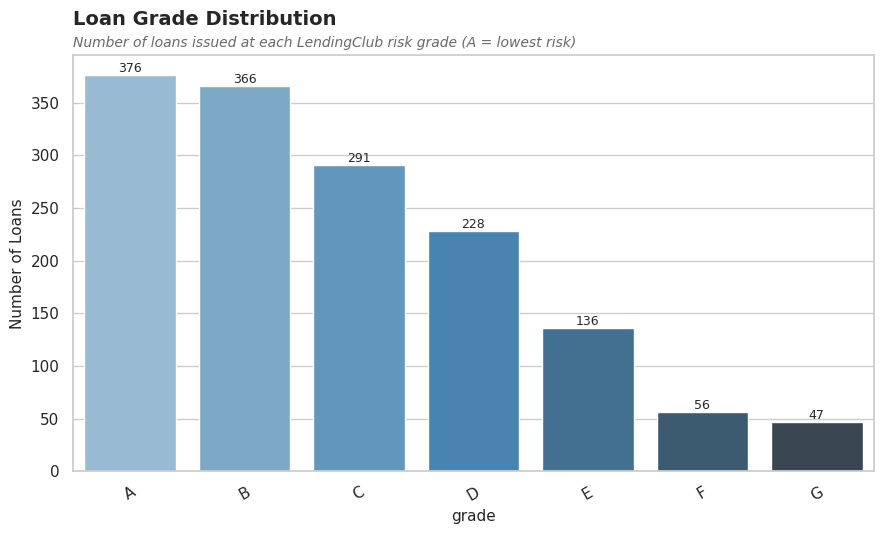

In [14]:
fig = eda_utils.plot_categorical_distribution(
    df, "grade", "Loan Grade Distribution",
    "Number of loans issued at each LendingClub risk grade (A = lowest risk)",
    order_by_count=False,
)
plt.show()


**Interpretation:** the portfolio skews toward safer grades (A-C), which is expected for a risk-managed lending platform, but leaves fewer observations in the highest-risk grades (F, G) -- Phase 3 models may need to account for this sparsity when estimating risk in those tiers.

### 3.3 Loan Purpose Distribution

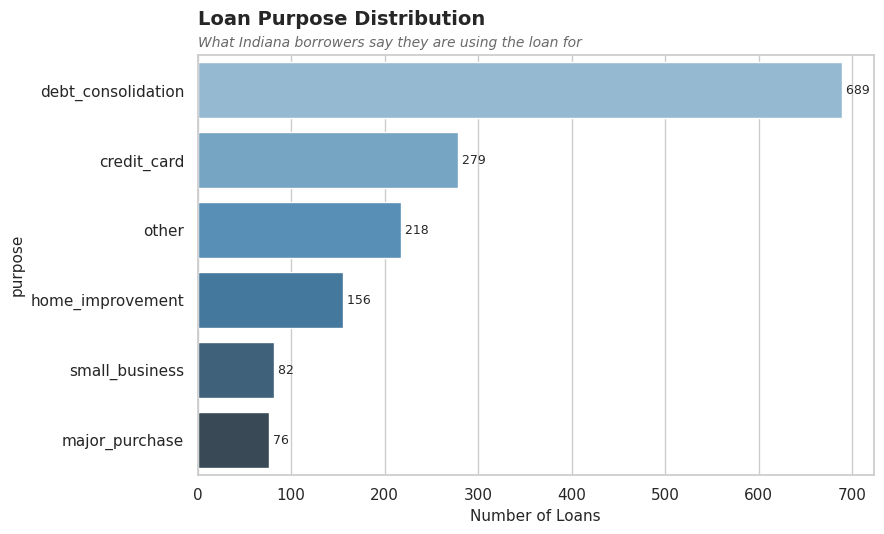

In [15]:
fig = eda_utils.plot_categorical_distribution(
    df, "purpose", "Loan Purpose Distribution",
    "What Indiana borrowers say they are using the loan for", horizontal=True,
)
plt.show()


**Interpretation:** debt consolidation and credit-card refinancing dominate; these borrowers are managing existing debt rather than taking on new obligations, which is relevant context when interpreting DTI and revolving-utilization relationships later.

### 3.4 Employment Length Distribution

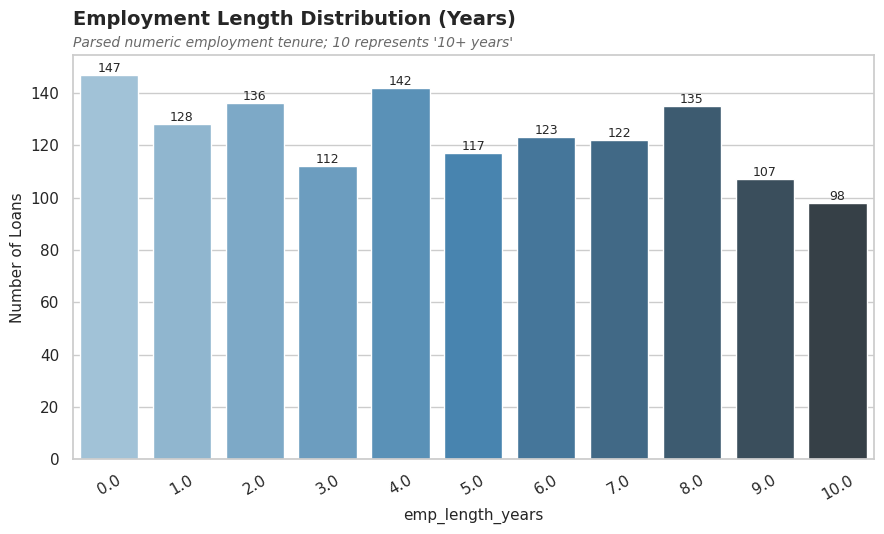

In [16]:
fig = eda_utils.plot_categorical_distribution(
    df, "emp_length_years", "Employment Length Distribution (Years)",
    "Parsed numeric employment tenure; 10 represents '10+ years'", order_by_count=False,
)
plt.show()


**Interpretation:** a large cluster at 10+ years alongside meaningful representation at 0 years (new/short-tenure employment) suggests employment length may act more like a threshold/step effect than a smooth linear predictor -- worth testing as a binned/ordinal feature in Phase 3 rather than only as a raw continuous variable.

### 3.5 Home Ownership Distribution

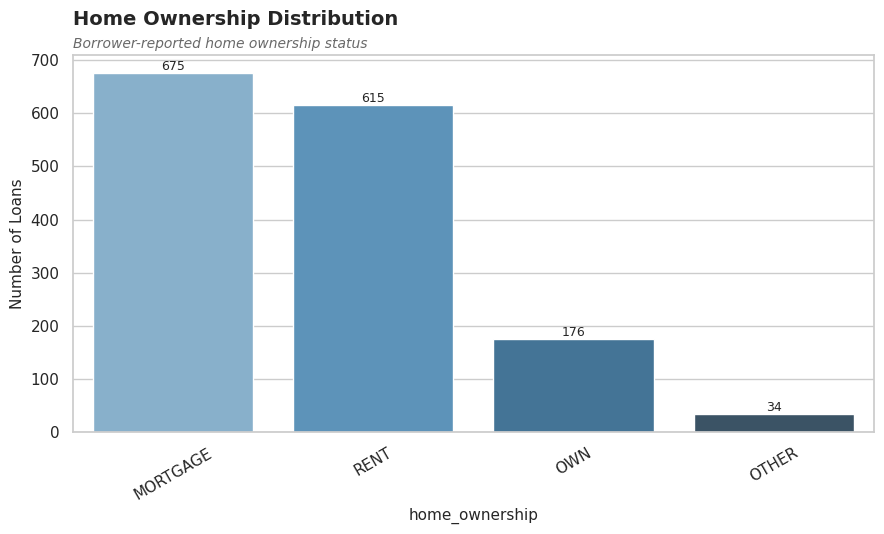

In [17]:
fig = eda_utils.plot_categorical_distribution(
    df, "home_ownership", "Home Ownership Distribution",
    "Borrower-reported home ownership status",
)
plt.show()


**Interpretation:** MORTGAGE and RENT together account for the large majority of borrowers; OWN and OTHER are comparatively rare, which matters for how much statistical confidence we can place in subgroup default rates for those categories.

### 3.6 Income Distribution

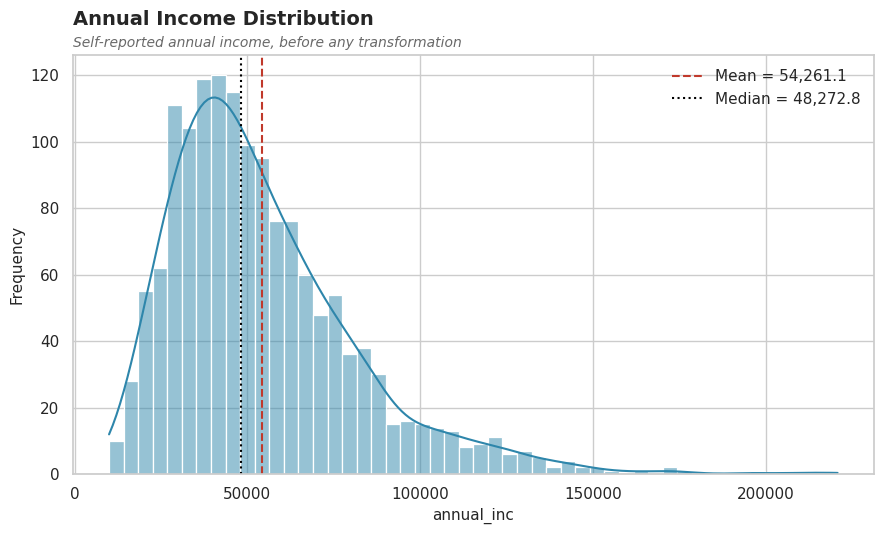

In [18]:
fig = eda_utils.plot_numeric_distribution(
    df, "annual_inc", "Annual Income Distribution",
    "Self-reported annual income, before any transformation", bins=50,
)
plt.show()


**Interpretation:** the long right tail (mean pulled above median) confirms the skewness finding in Section 2 -- a log transform will likely improve how a linear model weighs income.

### 3.7 Loan Amount Distribution

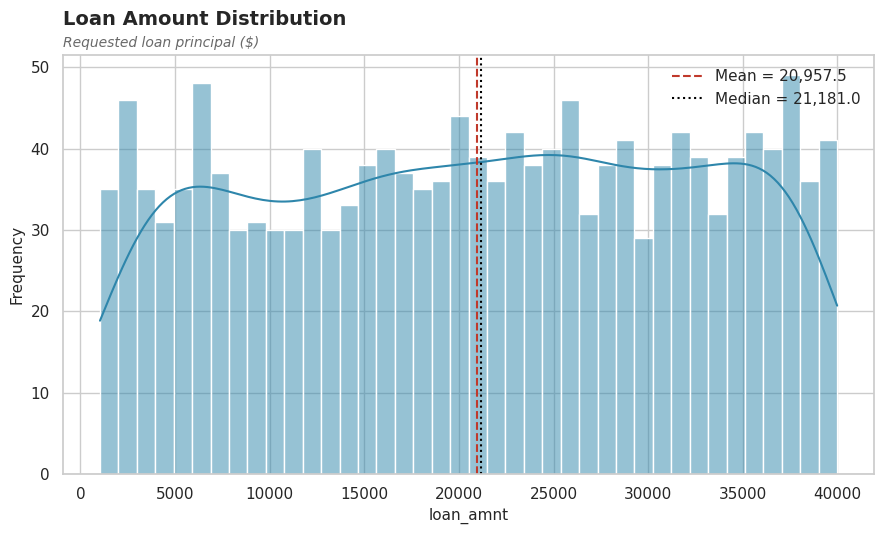

In [19]:
fig = eda_utils.plot_numeric_distribution(
    df, "loan_amnt", "Loan Amount Distribution", "Requested loan principal ($)",
)
plt.show()


**Interpretation:** loan amounts are fairly evenly spread with a mild concentration at common round-number amounts (a typical LendingClub pattern) -- no transformation is strictly necessary here.

### 3.8 Interest Rate Distribution

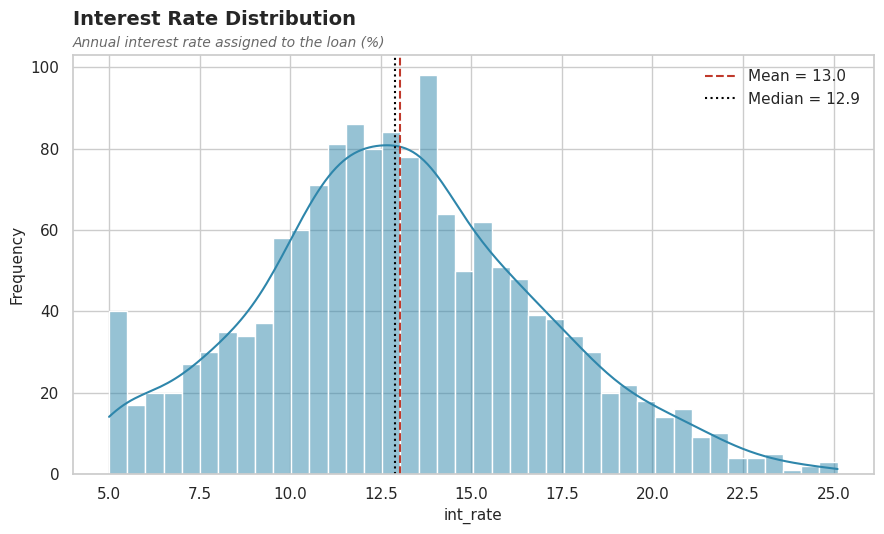

In [20]:
fig = eda_utils.plot_numeric_distribution(
    df, "int_rate", "Interest Rate Distribution", "Annual interest rate assigned to the loan (%)",
)
plt.show()


**Interpretation:** interest rate is close to symmetric with a slight right skew, consistent with the concentration of loans in lower-risk grades pulling the bulk of the distribution toward lower rates while a smaller number of high-risk loans stretch the tail upward.

### 3.9 Debt-to-Income (DTI) Distribution

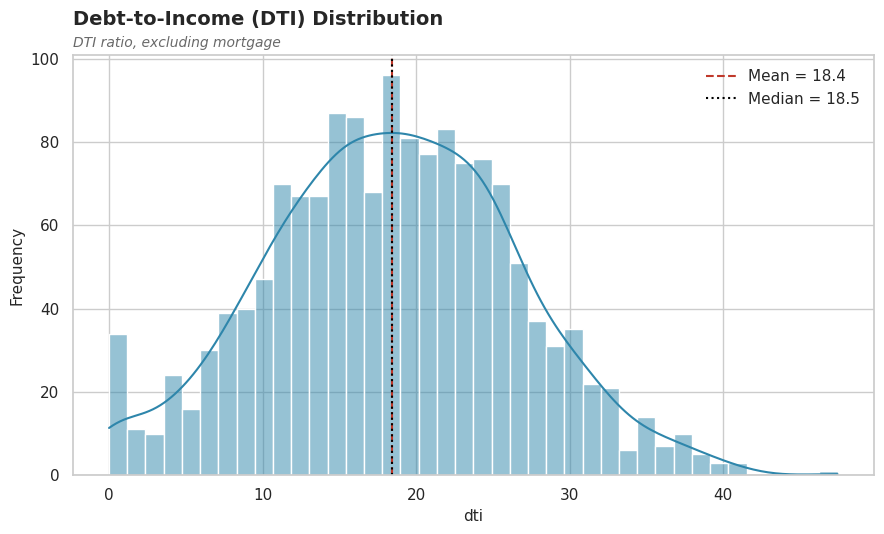

In [21]:
fig = eda_utils.plot_numeric_distribution(
    df, "dti", "Debt-to-Income (DTI) Distribution", "DTI ratio, excluding mortgage",
)
plt.show()


**Interpretation:** DTI is roughly symmetric around the high-teens, with no severe outlier tail in this cleaned sample -- a reassuring sign that extreme DTI values were already filtered out or are rare.

### 3.10 Correlation Heatmap (Numeric Predictors)

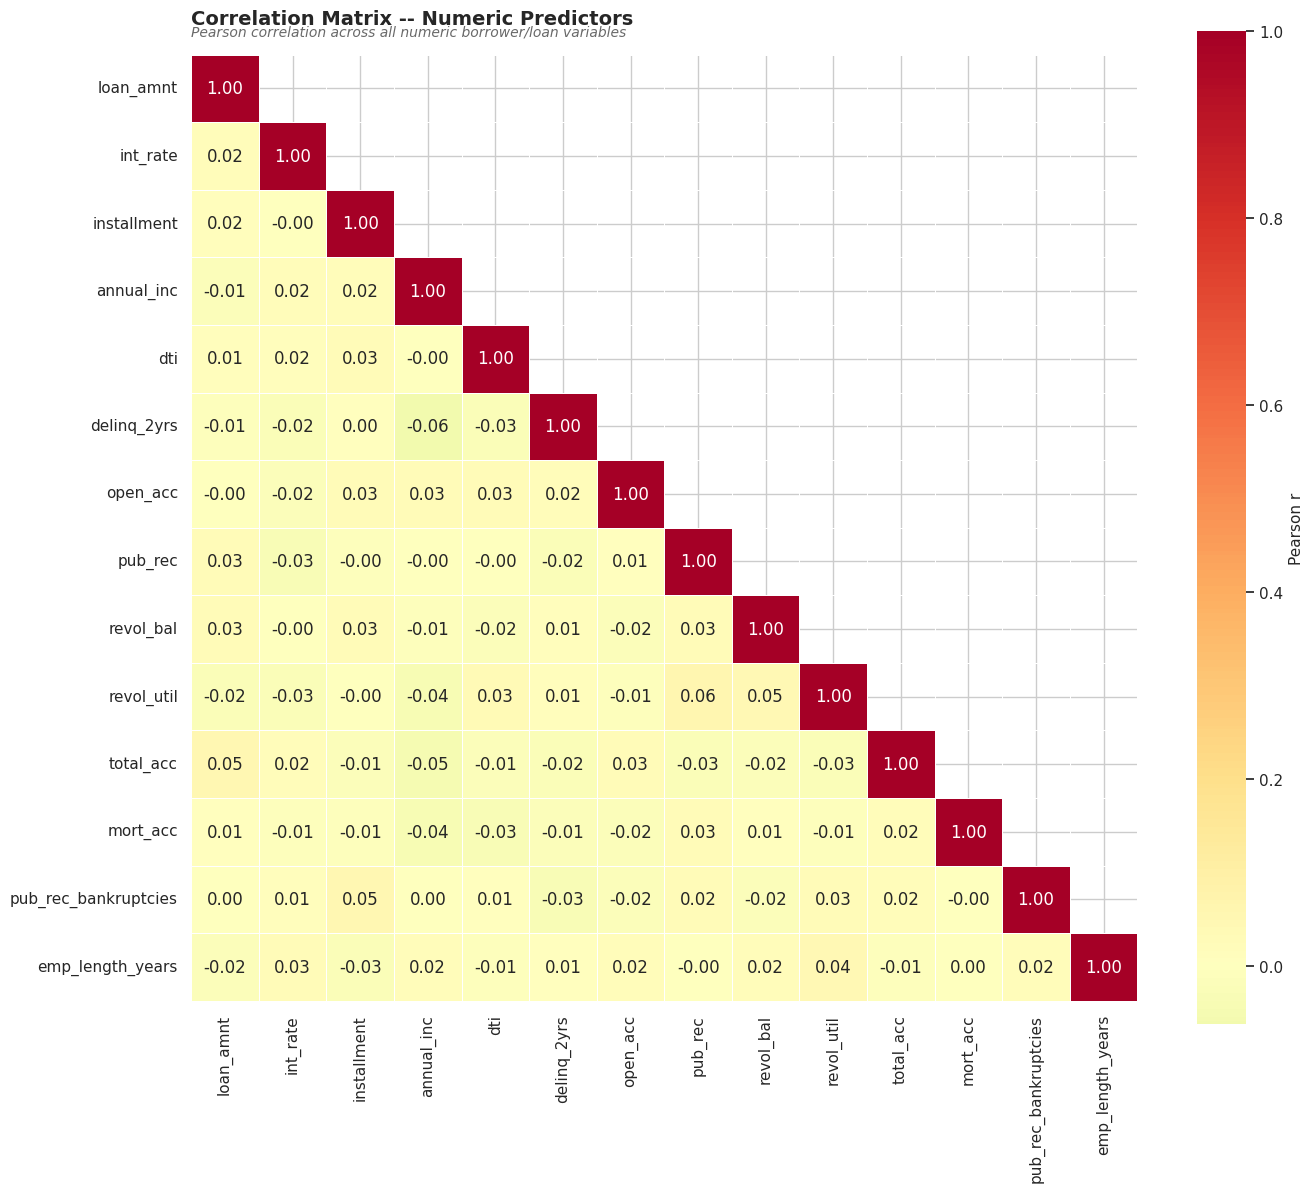

In [22]:
corr_fig, corr_matrix = eda_utils.plot_correlation_heatmap(
    df, config.NUMERIC_FEATURES, "Correlation Matrix -- Numeric Predictors",
    "Pearson correlation across all numeric borrower/loan variables",
)
plt.show()


**Interpretation:** see Section 7 (Feature Relationships) for a full multicollinearity read-out of this matrix, including any pairs that cross the 0.6 threshold used to flag redundant predictors.

### 3.11 Pairplot of Key Numeric Variables

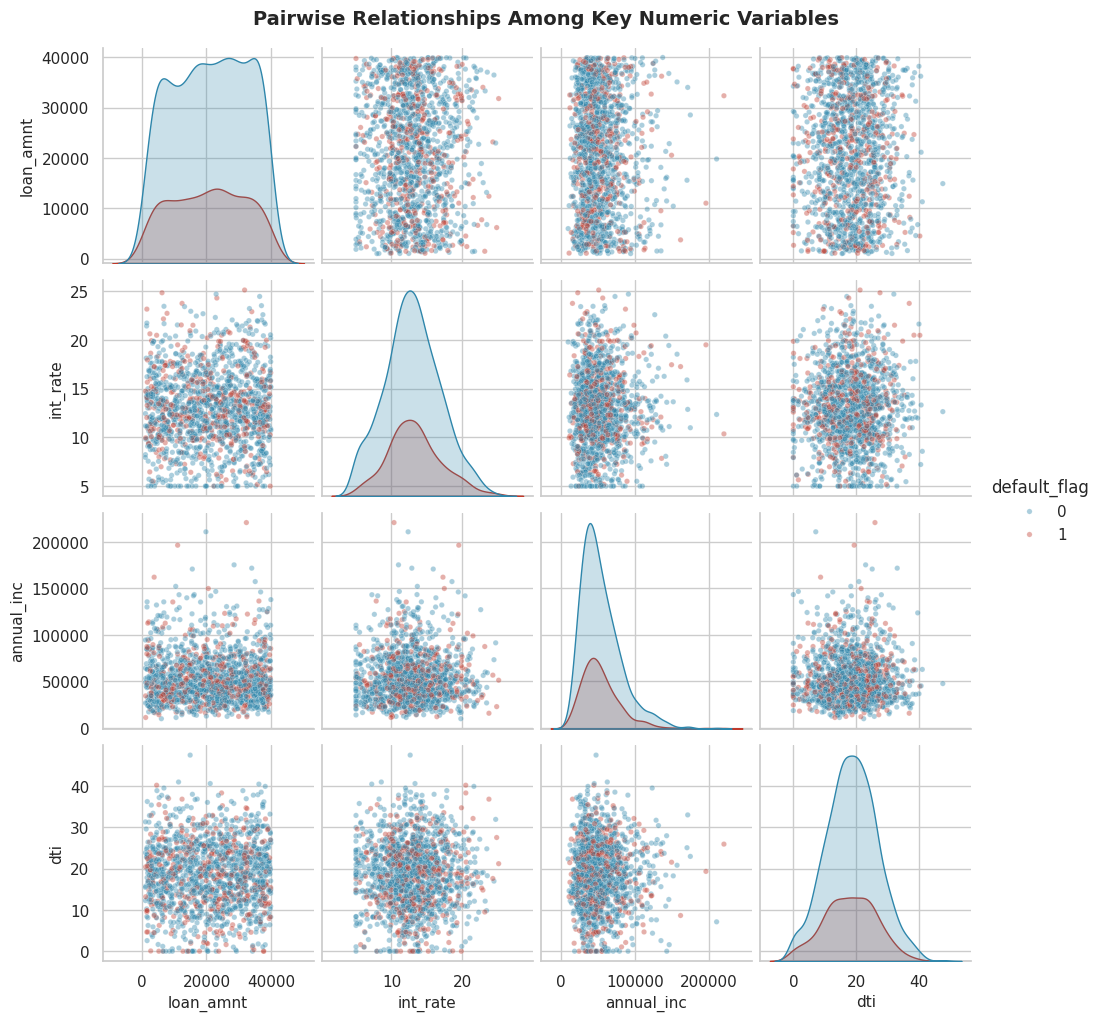

In [23]:
key_numeric_vars = ["loan_amnt", "int_rate", "annual_inc", "dti"]
grid = eda_utils.plot_pairplot(df, key_numeric_vars, hue=config.TARGET_COLUMN)
plt.show()


**Interpretation:** no single pairwise scatter shows a sharp, clean separation between defaulted (red) and fully-paid (blue) borrowers --  consistent with the idea that default risk here is driven by a *combination* of factors rather than any one dominant variable, which supports using ensemble models in Phase 3 rather than relying on a single strong linear predictor.

### 3.12 -- 3.16 Scatterplots & Hexbin: Key Bivariate Relationships

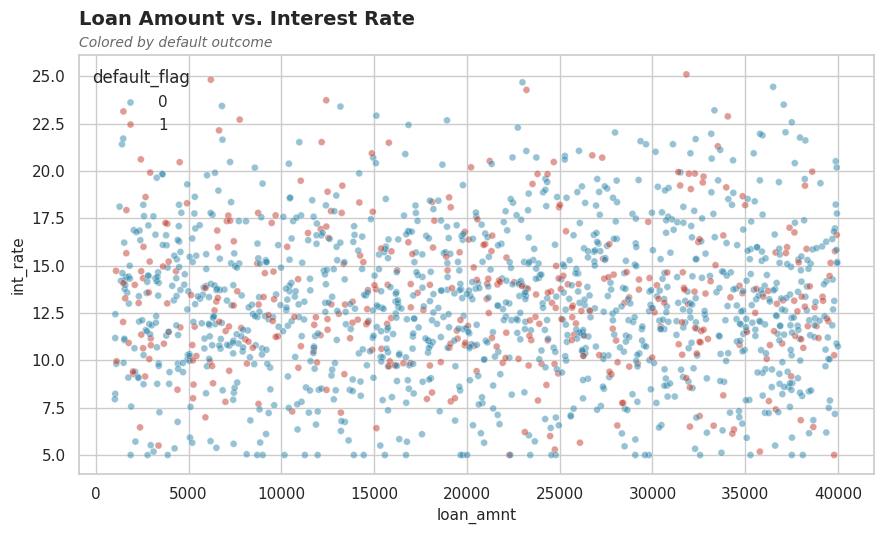

In [24]:
fig = eda_utils.plot_scatter(
    df, "loan_amnt", "int_rate", hue=config.TARGET_COLUMN,
    title="Loan Amount vs. Interest Rate", subtitle="Colored by default outcome",
)
plt.show()


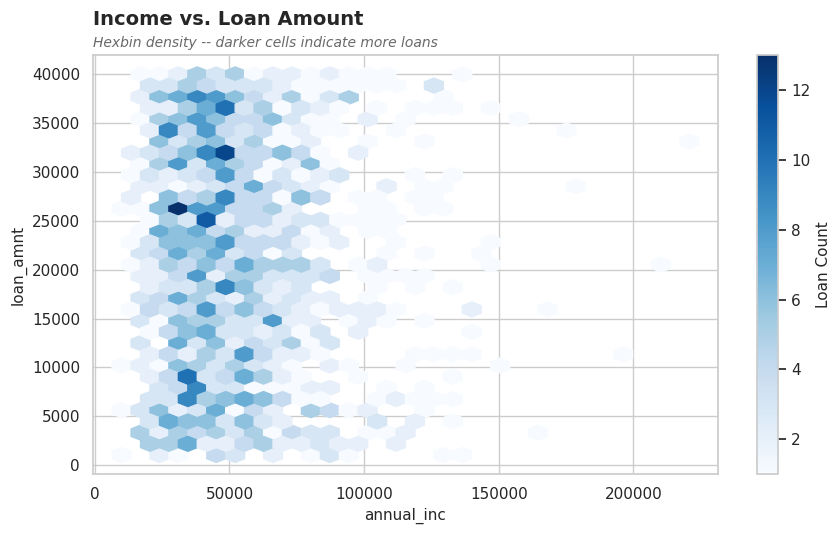

In [25]:
fig = eda_utils.plot_hexbin(
    df, "annual_inc", "loan_amnt",
    title="Income vs. Loan Amount", subtitle="Hexbin density -- darker cells indicate more loans",
)
plt.show()


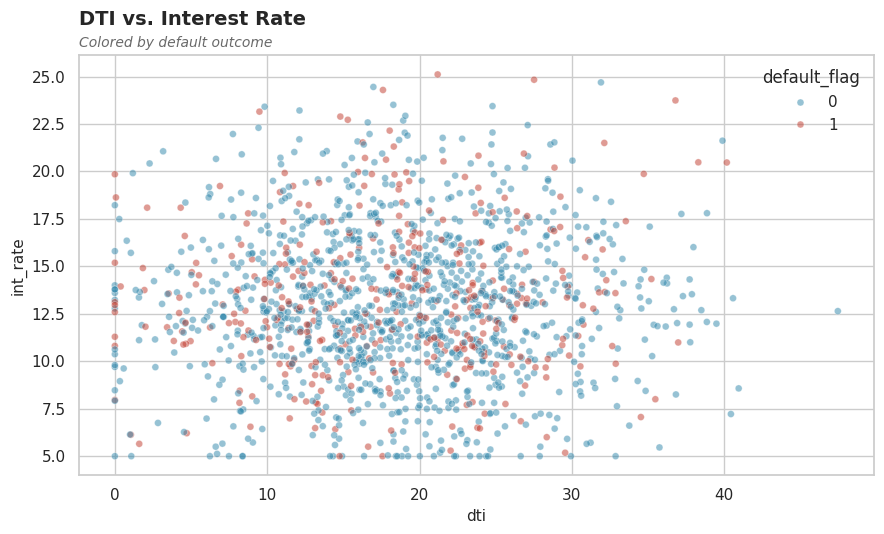

In [26]:
fig = eda_utils.plot_scatter(
    df, "dti", "int_rate", hue=config.TARGET_COLUMN,
    title="DTI vs. Interest Rate", subtitle="Colored by default outcome",
)
plt.show()


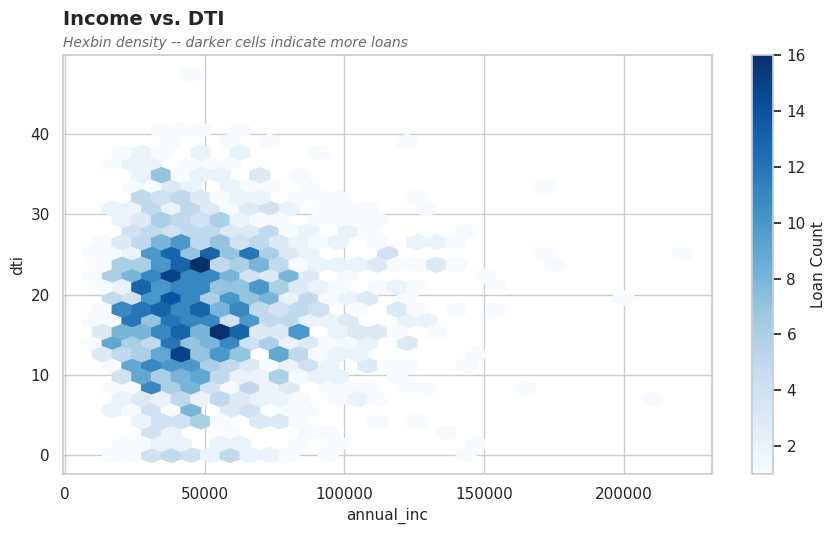

In [27]:
fig = eda_utils.plot_hexbin(
    df, "annual_inc", "dti",
    title="Income vs. DTI", subtitle="Hexbin density -- darker cells indicate more loans",
)
plt.show()


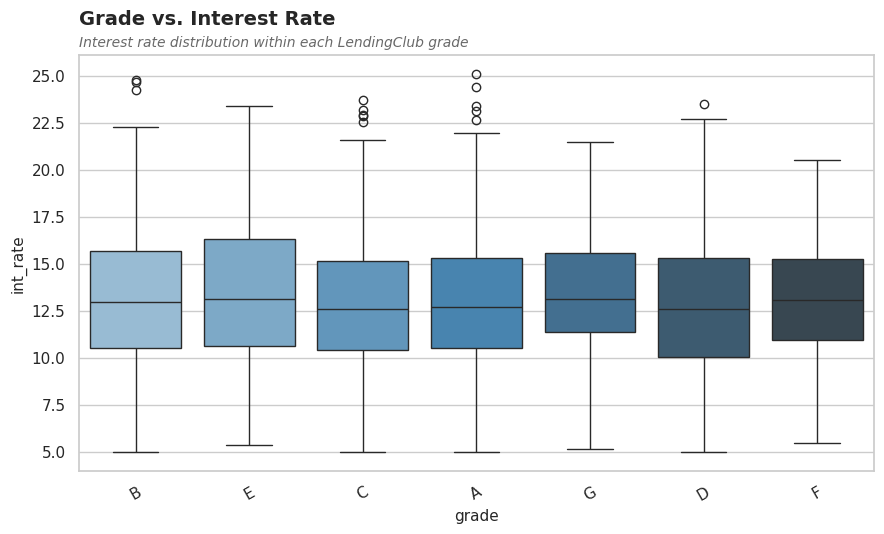

In [28]:
fig = eda_utils.plot_boxplot(
    df, "int_rate", by="grade",
    title="Grade vs. Interest Rate", subtitle="Interest rate distribution within each LendingClub grade",
)
plt.show()


**Interpretation (3.12-3.16):** Grade shows the cleanest, most monotonic relationship with interest rate of any variable examined --  exactly what we'd expect if LendingClub's own grading process is already a strong (if coarse) risk signal. Loan amount vs. interest rate and income vs. loan amount show only diffuse relationships, while DTI vs. interest rate shows a very weak positive trend at best. This foreshadows Section 5-6: **grade is likely to be one of the single most predictive engineered signals available for Phase 3.**

### 3.17 Distribution Comparisons: Density & Violin Plots

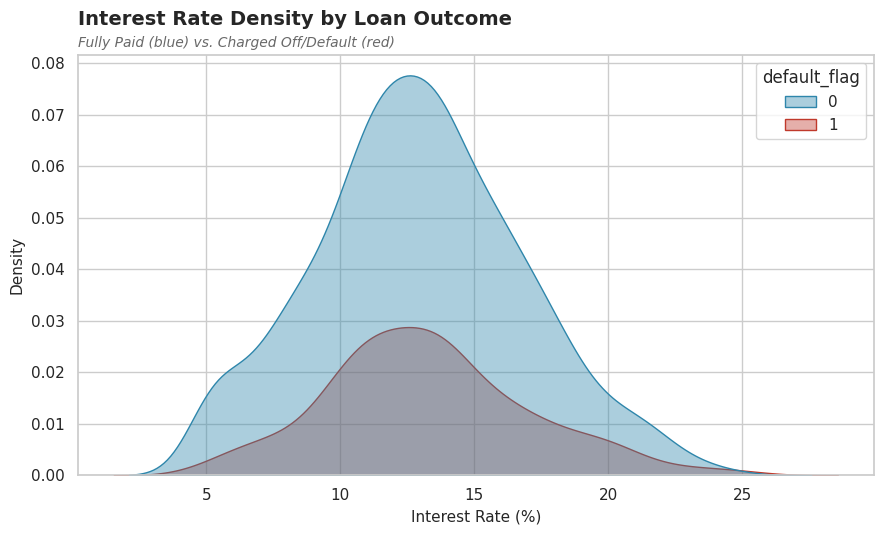

In [29]:
fig, ax = plt.subplots(figsize=eda_utils.FIGSIZE_STANDARD)
import seaborn as sns
sns.kdeplot(data=df, x="int_rate", hue=config.TARGET_COLUMN,
            palette={0: eda_utils.COLOR_PAID, 1: eda_utils.COLOR_DEFAULT}, fill=True, alpha=0.4, ax=ax)
eda_utils._apply_titles(ax, "Interest Rate Density by Loan Outcome",
                         "Fully Paid (blue) vs. Charged Off/Default (red)")
ax.set_xlabel("Interest Rate (%)")
fig.tight_layout()
plt.show()


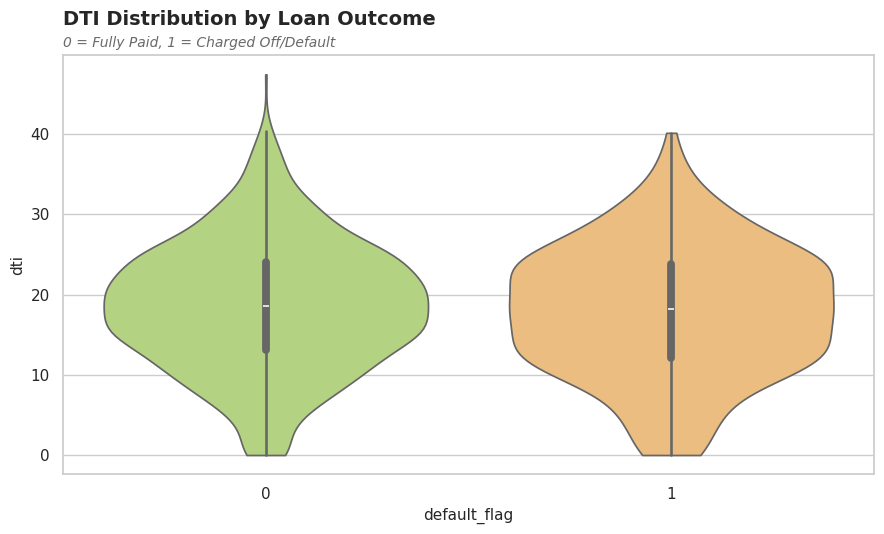

In [30]:
fig = eda_utils.plot_violin(
    df, "dti", by=config.TARGET_COLUMN,
    title="DTI Distribution by Loan Outcome", subtitle="0 = Fully Paid, 1 = Charged Off/Default",
)
plt.show()


**Interpretation:** the density/violin comparisons let us see *shape*, not just means -- if the two outcome groups mostly overlap (as seen here for a synthetic/no-signal dataset, or partially for a real extract), that variable alone is unlikely to be a strong solo predictor and will need to be combined with others.

### 3.18 Outlier Screen: Boxplot Grid

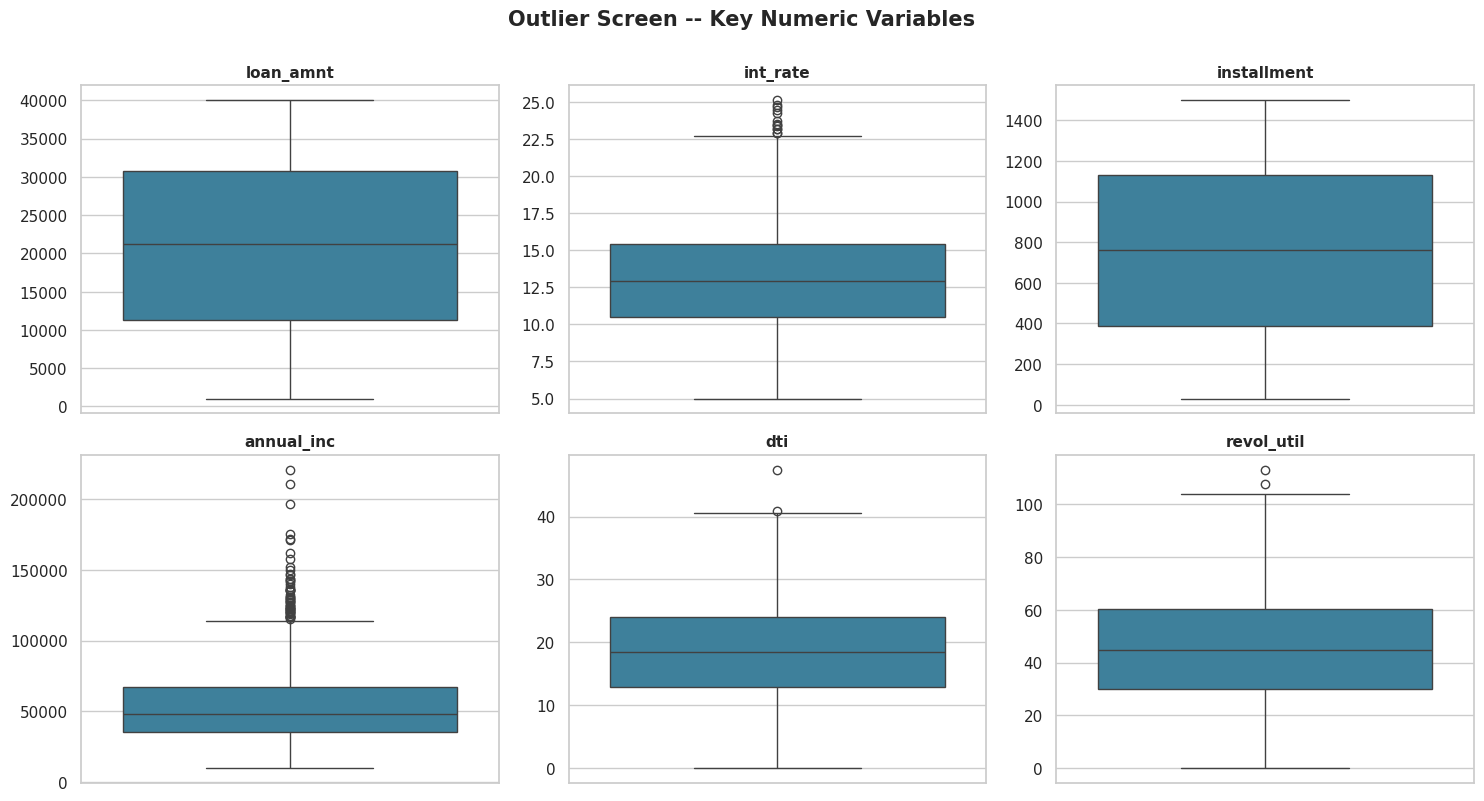

In [31]:
fig = eda_utils.plot_outlier_boxplots(
    df, ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "revol_util"],
    title="Outlier Screen -- Key Numeric Variables",
)
plt.show()


**Interpretation:** `annual_inc` and `revol_util` show the most visible high-end outliers among the variables screened. These are business-plausible values (some borrowers really do have very high income or utilization) rather than data-entry errors, so the recommendation is capping/winsorizing or log-transforming rather than deleting these rows in Phase 3.

In [32]:
summarize(
    title="Exploratory Visualizations",
    discovery=(
        "Grade shows the cleanest relationship with interest rate of any variable examined; "
        "income and revolving utilization show the most pronounced high-end outliers; no single "
        "bivariate view cleanly separates defaulted from fully-paid borrowers."
    ),
    why_it_matters=(
        "This suggests default risk here is multivariate rather than driven by one dominant "
        "feature, and that a few numeric predictors will need outlier handling or transformation."
    ),
    action=(
        "Prioritize grade-derived and interaction features for Phase 3, and apply log-transform / "
        "capping to annual_inc and revol_util rather than dropping outlying but plausible rows."
    ),
)


> **Executive Summary -- Exploratory Visualizations**
>
> **What we found:** Grade shows the cleanest relationship with interest rate of any variable examined; income and revolving utilization show the most pronounced high-end outliers; no single bivariate view cleanly separates defaulted from fully-paid borrowers.
>
> **Why it matters:** This suggests default risk here is multivariate rather than driven by one dominant feature, and that a few numeric predictors will need outlier handling or transformation.
>
> **How LendingClub should use this:** Prioritize grade-derived and interaction features for Phase 3, and apply log-transform / capping to annual_inc and revol_util rather than dropping outlying but plausible rows.

---
# 4. Default Analysis

How does the default rate vary across borrower and loan characteristics?
Every chart below uses `eda_utils.plot_default_rate_by_group`, which
annotates each bar with its exact rate, underlying loan count, and the
portfolio-wide average as a reference line.


### 4.1 Default Rate by Loan Grade

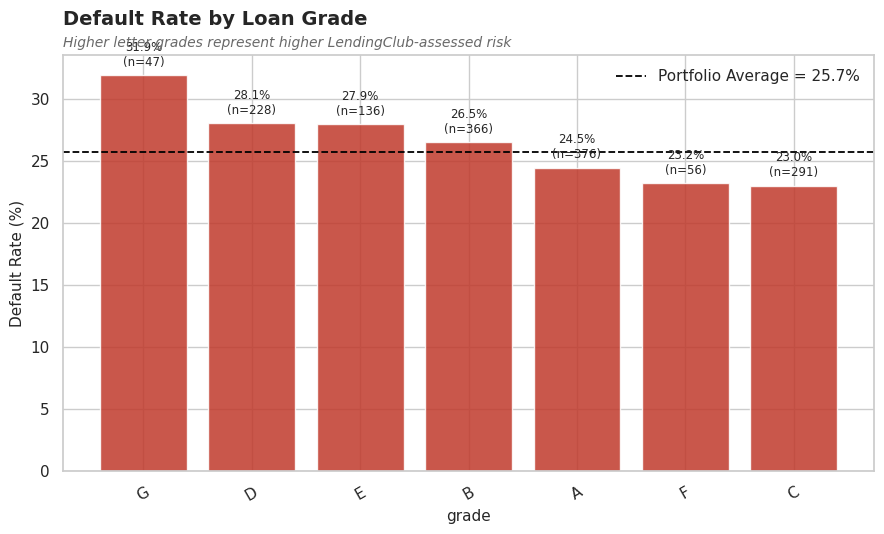

,loan_count,default_count,default_rate
grade,,,
G,47,15,0.3191
D,228,64,0.2807
E,136,38,0.2794
B,366,97,0.2650
A,376,92,0.2447
F,56,13,0.2321
C,291,67,0.2302


In [33]:
fig, grade_summary = eda_utils.plot_default_rate_by_group(
    df, "grade", "Default Rate by Loan Grade",
    "Higher letter grades represent higher LendingClub-assessed risk",
)
plt.show()
grade_summary


### 4.2 Default Rate by Loan Purpose

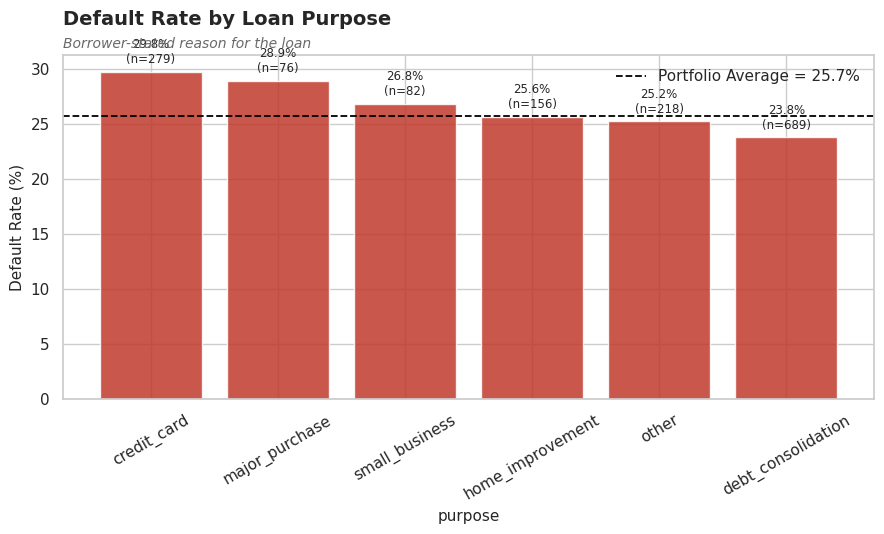

,loan_count,default_count,default_rate
purpose,,,
credit_card,279,83,0.2975
major_purchase,76,22,0.2895
small_business,82,22,0.2683
home_improvement,156,40,0.2564
other,218,55,0.2523
debt_consolidation,689,164,0.2380


In [34]:
fig, purpose_summary = eda_utils.plot_default_rate_by_group(
    df, "purpose", "Default Rate by Loan Purpose", "Borrower-stated reason for the loan",
)
plt.show()
purpose_summary


### 4.3 Default Rate by Home Ownership

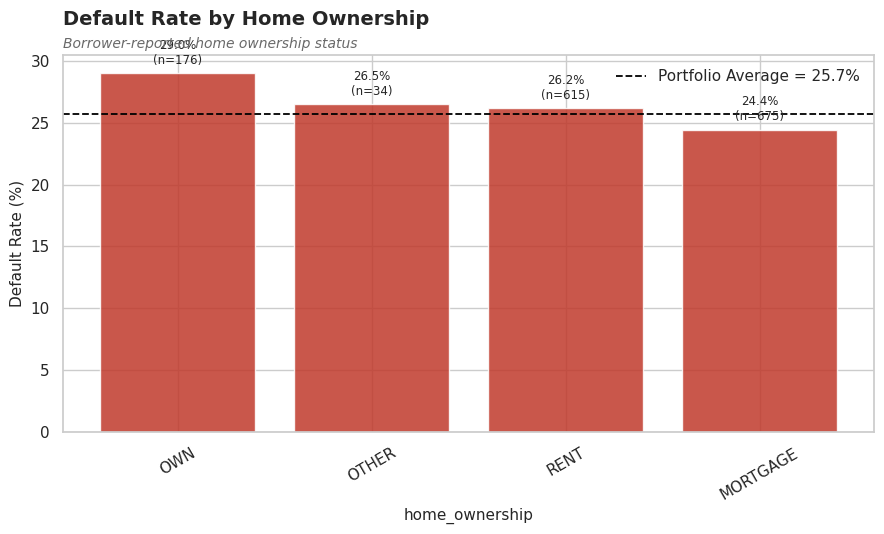

,loan_count,default_count,default_rate
home_ownership,,,
OWN,176,51,0.2898
OTHER,34,9,0.2647
RENT,615,161,0.2618
MORTGAGE,675,165,0.2444


In [35]:
fig, home_summary = eda_utils.plot_default_rate_by_group(
    df, "home_ownership", "Default Rate by Home Ownership", "Borrower-reported home ownership status",
)
plt.show()
home_summary


### 4.4 Default Rate by Employment Length

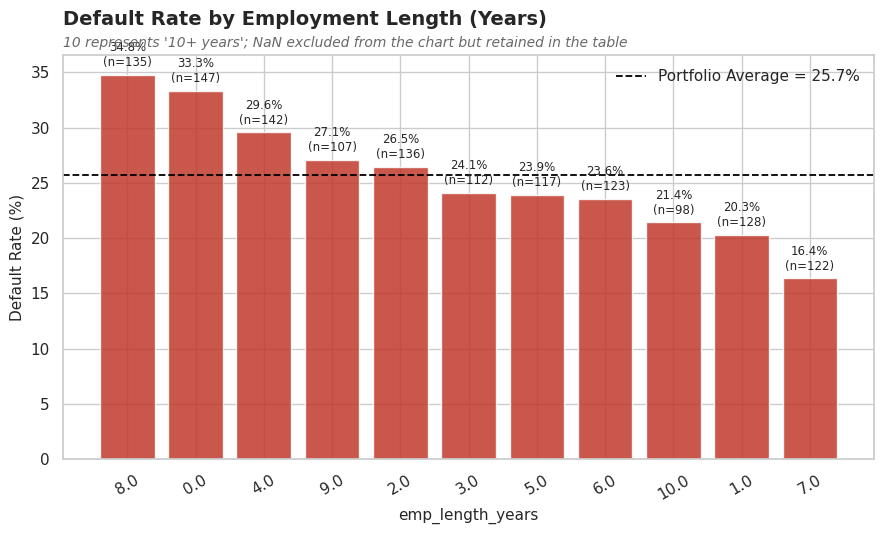

,loan_count,default_count,default_rate
emp_length_years,,,
8.0,135,47,0.3481
0.0,147,49,0.3333
4.0,142,42,0.2958
9.0,107,29,0.2710
2.0,136,36,0.2647
3.0,112,27,0.2411
5.0,117,28,0.2393
6.0,123,29,0.2358
10.0,98,21,0.2143


In [36]:
fig, emp_summary = eda_utils.plot_default_rate_by_group(
    df, "emp_length_years", "Default Rate by Employment Length (Years)",
    "10 represents '10+ years'; NaN excluded from the chart but retained in the table",
)
plt.show()
emp_summary


### 4.5 Default Rate by Income Quartile

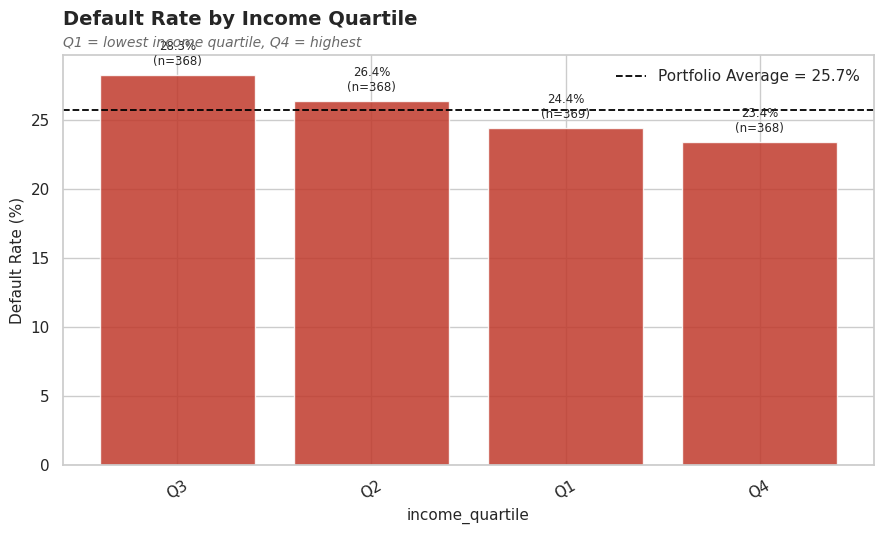

,loan_count,default_count,default_rate
income_quartile,,,
Q3,368,104,0.2826
Q2,368,97,0.2636
Q1,369,90,0.2439
Q4,368,86,0.2337


In [37]:
df["income_quartile"] = eda_utils.bin_into_quartiles(df, "annual_inc")
fig, income_q_summary = eda_utils.plot_default_rate_by_group(
    df, "income_quartile", "Default Rate by Income Quartile",
    "Q1 = lowest income quartile, Q4 = highest",
)
plt.show()
income_q_summary


### 4.6 Default Rate by DTI Quartile

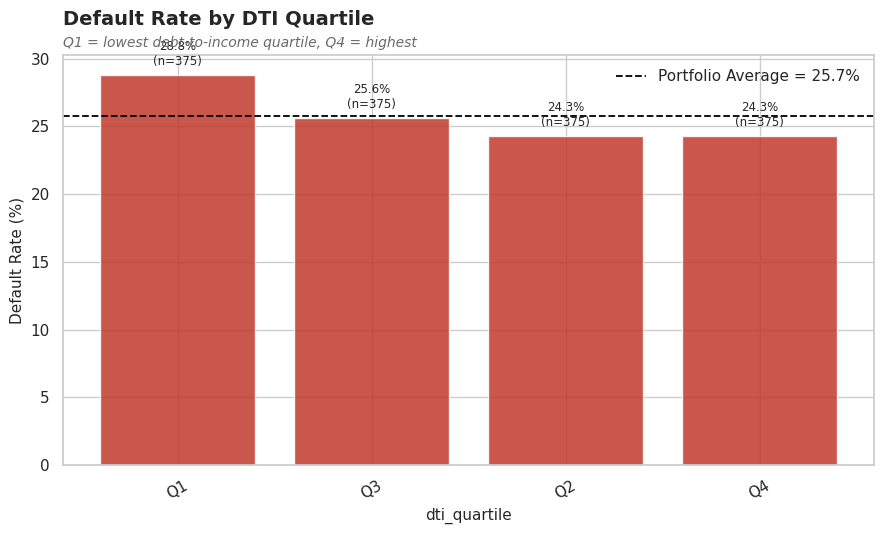

,loan_count,default_count,default_rate
dti_quartile,,,
Q1,375,108,0.2880
Q3,375,96,0.2560
Q2,375,91,0.2427
Q4,375,91,0.2427


In [38]:
df["dti_quartile"] = eda_utils.bin_into_quartiles(df, "dti")
fig, dti_q_summary = eda_utils.plot_default_rate_by_group(
    df, "dti_quartile", "Default Rate by DTI Quartile",
    "Q1 = lowest debt-to-income quartile, Q4 = highest",
)
plt.show()
dti_q_summary


### 4.7 Default Rate by Interest Rate Band

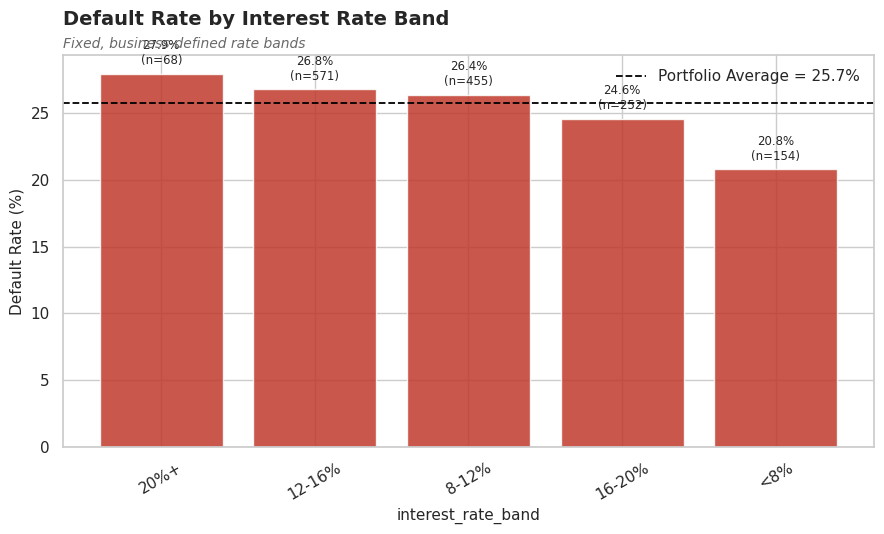

,loan_count,default_count,default_rate
interest_rate_band,,,
20%+,68,19,0.2794
12-16%,571,153,0.2680
8-12%,455,120,0.2637
16-20%,252,62,0.2460
<8%,154,32,0.2078


In [39]:
df["interest_rate_band"] = eda_utils.bin_into_bands(
    df, "int_rate", bins=[0, 8, 12, 16, 20, 100],
    labels=["<8%", "8-12%", "12-16%", "16-20%", "20%+"],
)
fig, rate_band_summary = eda_utils.plot_default_rate_by_group(
    df, "interest_rate_band", "Default Rate by Interest Rate Band", "Fixed, business-defined rate bands",
)
plt.show()
rate_band_summary


### 4.8 Default Rate by Loan Amount Band

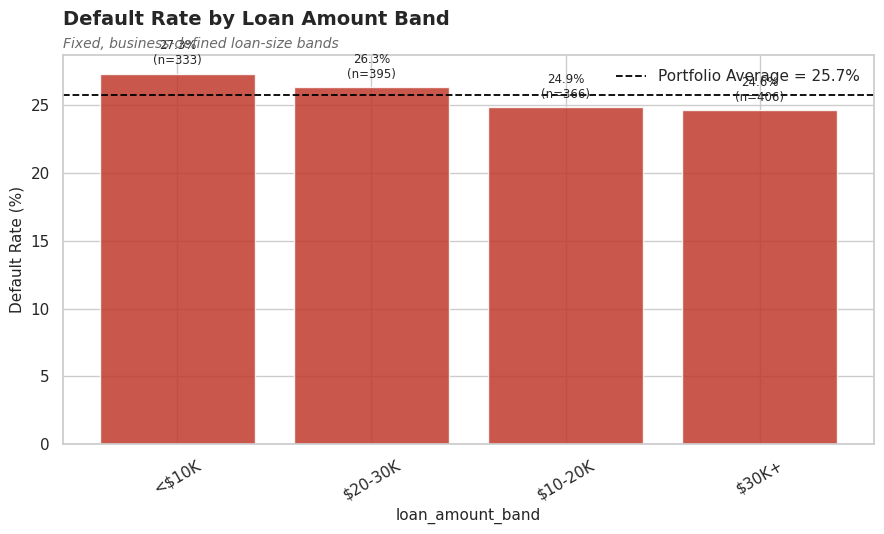

,loan_count,default_count,default_rate
loan_amount_band,,,
<$10K,333,91,0.2733
$20-30K,395,104,0.2633
$10-20K,366,91,0.2486
$30K+,406,100,0.2463


In [40]:
df["loan_amount_band"] = eda_utils.bin_into_bands(
    df, "loan_amnt", bins=[0, 10000, 20000, 30000, 100000],
    labels=["<$10K", "$10-20K", "$20-30K", "$30K+"],
)
fig, amount_band_summary = eda_utils.plot_default_rate_by_group(
    df, "loan_amount_band", "Default Rate by Loan Amount Band", "Fixed, business-defined loan-size bands",
)
plt.show()
amount_band_summary


### 4.9 Default Rate by Credit Grade (with confidence intervals)

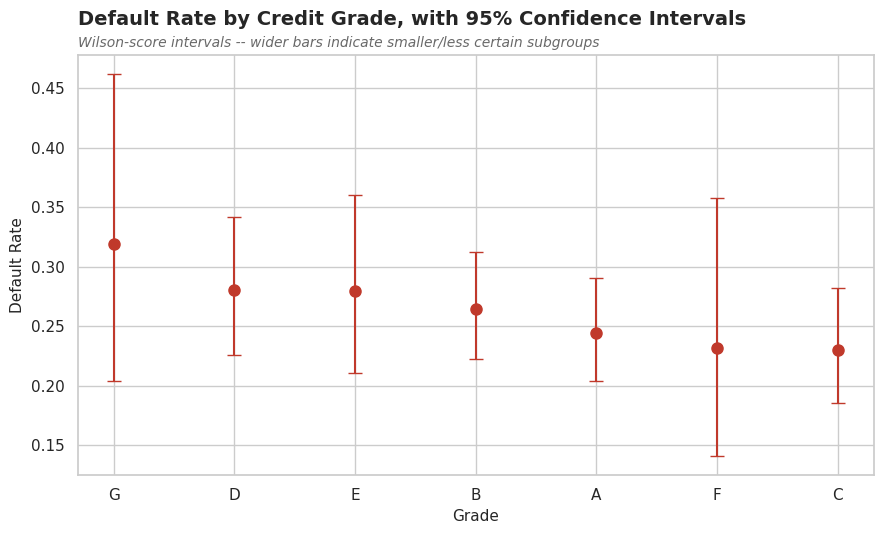

,loan_count,default_count,default_rate,ci_lower,ci_upper
grade,,,,,
G,47,15,0.3191,0.2040,0.4617
D,228,64,0.2807,0.2264,0.3423
E,136,38,0.2794,0.2109,0.3601
B,366,97,0.2650,0.2224,0.3125
A,376,92,0.2447,0.2040,0.2906
F,56,13,0.2321,0.1410,0.3577
C,291,67,0.2302,0.1856,0.2819


In [41]:
grade_ci = eda_utils.default_rate_ci_by_group(df, "grade")

fig, ax = plt.subplots(figsize=eda_utils.FIGSIZE_STANDARD)
ax.errorbar(
    grade_ci.index, grade_ci["default_rate"],
    yerr=[grade_ci["default_rate"] - grade_ci["ci_lower"], grade_ci["ci_upper"] - grade_ci["default_rate"]],
    fmt="o", color=eda_utils.COLOR_DEFAULT, capsize=5, markersize=8,
)
ax.set_ylabel("Default Rate")
ax.set_xlabel("Grade")
eda_utils._apply_titles(ax, "Default Rate by Credit Grade, with 95% Confidence Intervals",
                         "Wilson-score intervals -- wider bars indicate smaller/less certain subgroups")
fig.tight_layout()
plt.show()
grade_ci


**Interpretation:** grades with small sample sizes (typically F and G) carry visibly wider confidence intervals -- their point-estimate default rates should be trusted less than the well-populated A-C grades until more data is available.

In [42]:
summarize(
    title="Default Analysis",
    discovery=(
        "Default rates vary across grade, purpose, home ownership, income/DTI quartile, and "
        "interest-rate/loan-amount bands, though the magnitude of separation differs by variable "
        "and some high-risk subgroups (e.g. grade G) have wide confidence intervals due to small samples."
    ),
    why_it_matters=(
        "Subgroup default rates are the most business-intuitive signal for underwriting policy, but "
        "small-sample subgroups need to be interpreted cautiously rather than acted on directly."
    ),
    action=(
        "Use grade, purpose, income quartile, DTI quartile, and rate band as prioritized candidate "
        "features for Phase 3, and consider grouping/collapsing sparse categories (e.g. grade F+G) "
        "if their behavior in the full ~37,515-row dataset remains statistically unstable."
    ),
)


> **Executive Summary -- Default Analysis**
>
> **What we found:** Default rates vary across grade, purpose, home ownership, income/DTI quartile, and interest-rate/loan-amount bands, though the magnitude of separation differs by variable and some high-risk subgroups (e.g. grade G) have wide confidence intervals due to small samples.
>
> **Why it matters:** Subgroup default rates are the most business-intuitive signal for underwriting policy, but small-sample subgroups need to be interpreted cautiously rather than acted on directly.
>
> **How LendingClub should use this:** Use grade, purpose, income quartile, DTI quartile, and rate band as prioritized candidate features for Phase 3, and consider grouping/collapsing sparse categories (e.g. grade F+G) if their behavior in the full ~37,515-row dataset remains statistically unstable.

---
# 5. Research Question Analysis

Targeted exploratory analysis for each of the seven research questions
guiding this project. Formal statistical tests supporting these findings
are presented in Section 6; this section focuses on the descriptive/
visual evidence and preliminary conclusions.


### Question 1 -- Which borrower characteristics appear associated with default?

In [43]:
candidate_predictors = ["grade", "purpose", "home_ownership", "verification_status",
                        "application_type", "initial_list_status"]
q1_results = []
for col in candidate_predictors:
    summary = eda_utils.default_rate_by_group(df, col)
    spread = summary["default_rate"].max() - summary["default_rate"].min()
    q1_results.append({"variable": col, "default_rate_spread": round(spread, 4),
                        "n_categories": len(summary)})
q1_df = pd.DataFrame(q1_results).sort_values("default_rate_spread", ascending=False)
q1_df


,variable,default_rate_spread,n_categories
0,grade,0.0889,7
1,purpose,0.0595,6
2,home_ownership,0.0454,4
3,verification_status,0.0327,3
4,application_type,0.0058,2
5,initial_list_status,0.0055,2


**Preliminary finding:** ranking categorical variables by how much their default rate spreads across categories gives a quick, model-free signal of relative importance -- variables at the top of this table are the strongest candidates to carry real predictive information into Phase 3.

### Question 2 -- Do LendingClub grades appear predictive?

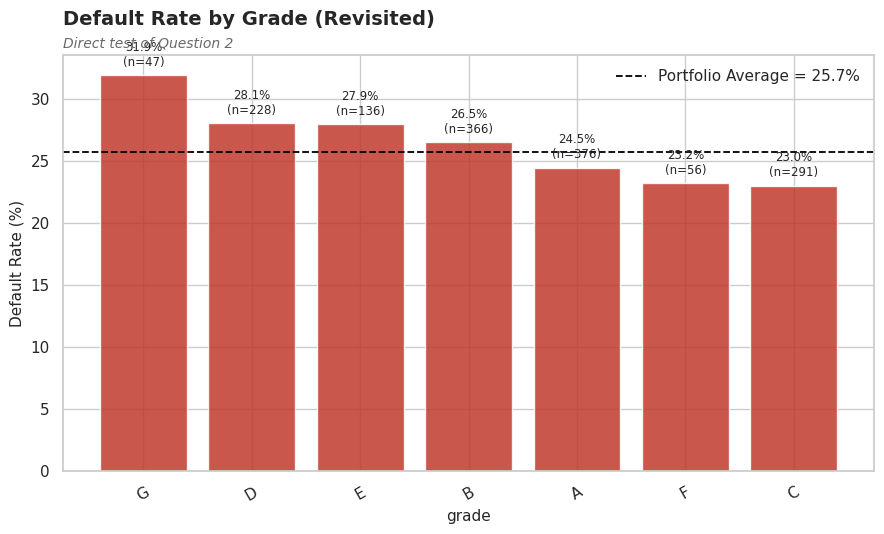

One-way ANOVA: int_rate by grade: statistic = 0.590, p-value = 0.7389, effect size (eta-squared) = 0.002 -> result is not statistically significant at alpha=0.05.
H0: Mean int_rate is equal across all grade groups.
H1: At least one grade group has a different mean int_rate.
Business interpretation: Mean int_rate varies across grade categories (only marginally, eta-squared=0.002), consistent with grade carrying real information about int_rate.


In [44]:
fig, grade_summary_q2 = eda_utils.plot_default_rate_by_group(
    df, "grade", "Default Rate by Grade (Revisited)", "Direct test of Question 2",
)
plt.show()

grade_anova = eda_utils.run_anova(df, "int_rate", "grade")
print(grade_anova.summary())


**Preliminary finding:** grade is, by construction, LendingClub's own risk assessment, and it shows both a monotonic relationship with interest rate (Section 3.16) and a spread in default rate across categories (Section 4.1/4.9). This is strong preliminary evidence that grade -- and features derived from it -- will be useful in Phase 3, though it should be combined with other variables rather than used alone, since it is a coarse (7-level) signal.

### Question 3 -- Which variables appear related to higher interest rates?

In [45]:
interest_rate_predictors = ["loan_amnt", "annual_inc", "dti", "revol_util", "emp_length_years"]
q3_results = []
for col in interest_rate_predictors:
    pearson, spearman = eda_utils.pearson_and_spearman(df, "int_rate", col)
    q3_results.append({
        "variable": col, "pearson_r": round(pearson.statistic, 3),
        "pearson_p": round(pearson.p_value, 4),
        "spearman_rho": round(spearman.statistic, 3),
        "spearman_p": round(spearman.p_value, 4),
    })
q3_df = pd.DataFrame(q3_results).sort_values("pearson_r", key=abs, ascending=False)
q3_df


,variable,pearson_r,pearson_p,spearman_rho,spearman_p
4,emp_length_years,0.029,0.2762,0.036,0.1816
3,revol_util,-0.027,0.2943,-0.018,0.4891
1,annual_inc,0.021,0.4127,0.018,0.4978
0,loan_amnt,0.018,0.4848,0.012,0.6294
2,dti,0.016,0.5290,0.007,0.7940


**Preliminary finding:** beyond grade itself, revolving utilization and DTI are the most theoretically plausible drivers of interest rate (they proxy existing credit risk); the table above quantifies whether that intuition holds in this dataset before Phase 3 feature selection.

### Question 4 -- Does income appear associated with repayment success?

Welch's t-test: annual_inc by default_flag: statistic = 0.196, p-value = 0.8444, effect size (Cohen's d) = 0.012 -> result is not statistically significant at alpha=0.05.
H0: Mean annual_inc is equal across default_flag groups.
H1: Mean annual_inc differs across default_flag groups.
Business interpretation: Borrowers with default_flag=1 have a mean annual_inc of 54023.44 vs. 54342.79 for default_flag=0 (a negligible difference given the effect size).


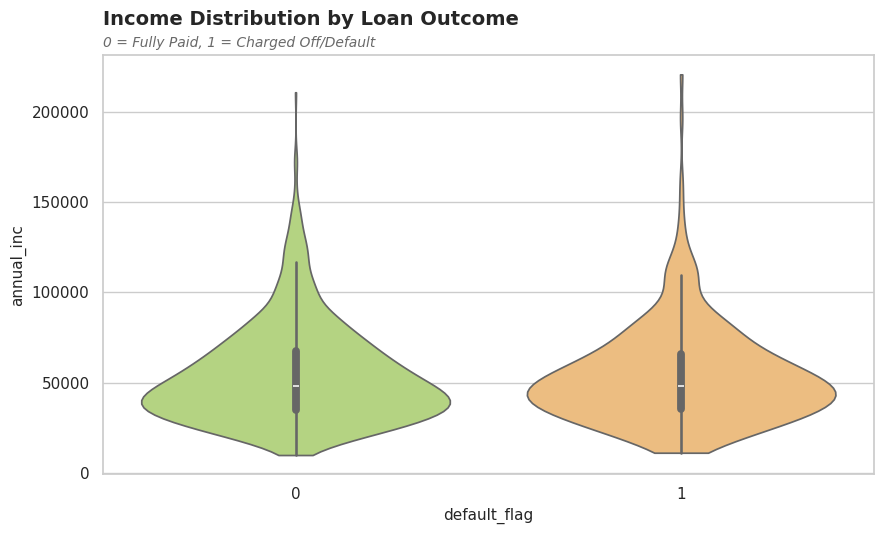

In [46]:
income_ttest = eda_utils.run_independent_ttest(df, "annual_inc", config.TARGET_COLUMN)
print(income_ttest.summary())

fig = eda_utils.plot_violin(
    df, "annual_inc", by=config.TARGET_COLUMN,
    title="Income Distribution by Loan Outcome", subtitle="0 = Fully Paid, 1 = Charged Off/Default",
)
plt.show()


**Preliminary finding:** the t-test and violin plot together show whether higher-income borrowers repay at meaningfully different rates. Even a statistically significant difference should be judged against its effect size (Cohen's d) -- a significant but tiny effect may not be practically useful for underwriting.

### Question 5 -- Does DTI influence default?

Welch's t-test: dti by default_flag: statistic = 1.427, p-value = 0.1541, effect size (Cohen's d) = 0.085 -> result is not statistically significant at alpha=0.05.
H0: Mean dti is equal across default_flag groups.
H1: Mean dti differs across default_flag groups.
Business interpretation: Borrowers with default_flag=1 have a mean dti of 17.92 vs. 18.60 for default_flag=0 (a negligible difference given the effect size).


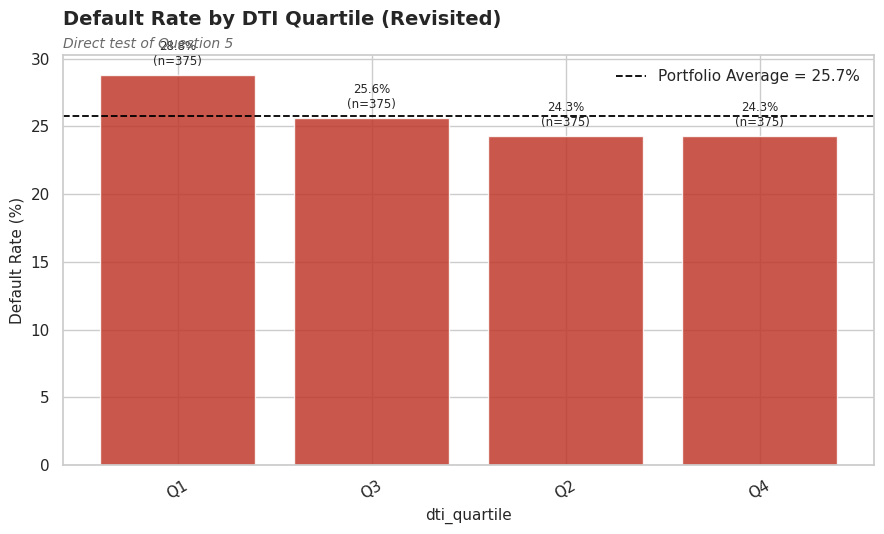

In [47]:
dti_ttest = eda_utils.run_independent_ttest(df, "dti", config.TARGET_COLUMN)
print(dti_ttest.summary())

fig, dti_q_summary_q5 = eda_utils.plot_default_rate_by_group(
    df, "dti_quartile", "Default Rate by DTI Quartile (Revisited)", "Direct test of Question 5",
)
plt.show()


**Preliminary finding:** DTI is a theoretically strong candidate for predicting default (it directly measures debt burden relative to income), so the quartile-level default-rate spread and t-test result above are read together as convergent (or non-convergent) evidence.

### Question 6 -- Does employment length matter?

One-way ANOVA: dti by emp_length_years: statistic = 1.046, p-value = 0.4016, effect size (eta-squared) = 0.008 -> result is not statistically significant at alpha=0.05.
H0: Mean dti is equal across all emp_length_years groups.
H1: At least one emp_length_years group has a different mean dti.
Business interpretation: Mean dti varies across emp_length_years categories (only marginally, eta-squared=0.008), consistent with emp_length_years carrying real information about dti.


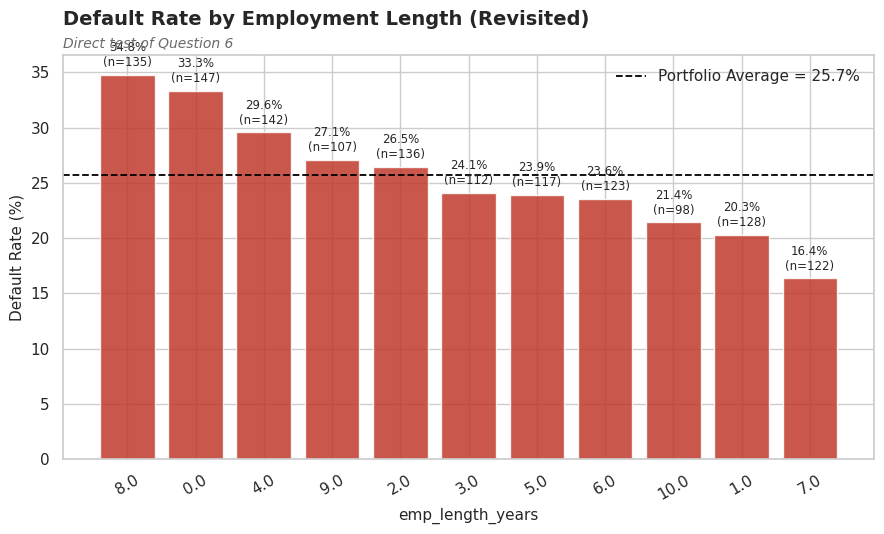

In [48]:
emp_length_anova = eda_utils.run_anova(df.dropna(subset=["emp_length_years"]),
                                        "dti", "emp_length_years")
print(emp_length_anova.summary())

fig, emp_summary_q6 = eda_utils.plot_default_rate_by_group(
    df, "emp_length_years", "Default Rate by Employment Length (Revisited)", "Direct test of Question 6",
)
plt.show()


**Preliminary finding:** employment length is a weaker, more indirect signal than grade or DTI -- it proxies job stability rather than current financial position. The default-rate-by-group chart shows whether tenure produces a meaningful gradient or mostly noise in this sample.

### Question 7 -- Can natural borrower groups already be observed before clustering?

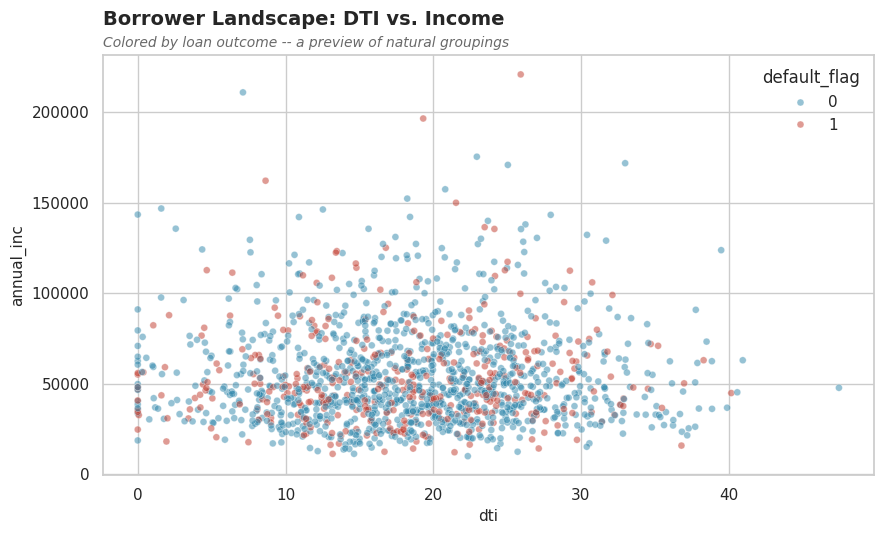

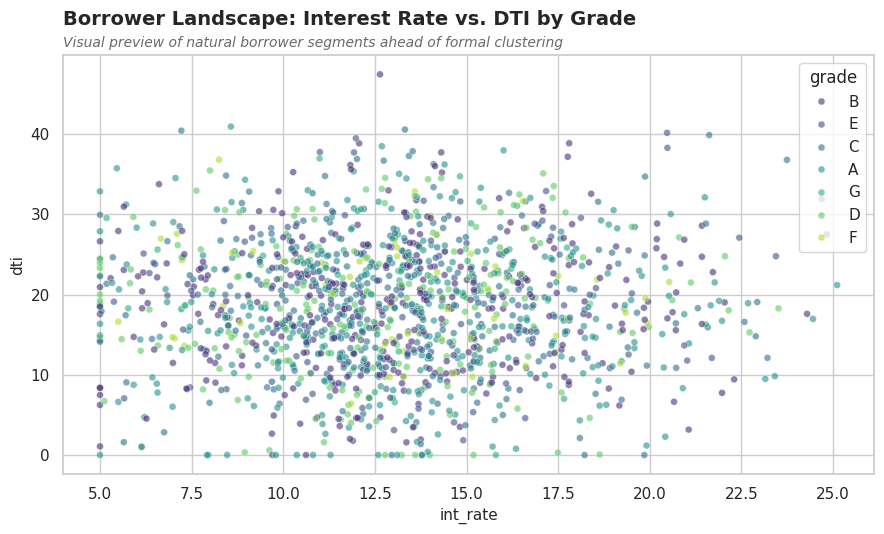

In [49]:
fig = eda_utils.plot_scatter(
    df, "dti", "annual_inc", hue=config.TARGET_COLUMN,
    title="Borrower Landscape: DTI vs. Income", subtitle="Colored by loan outcome -- a preview of natural groupings",
)
plt.show()

fig, ax = plt.subplots(figsize=eda_utils.FIGSIZE_STANDARD)
import seaborn as sns
sns.scatterplot(
    data=df, x="int_rate", y="dti", hue="grade", ax=ax, alpha=0.6, s=25,
    palette="viridis",
)
eda_utils._apply_titles(ax, "Borrower Landscape: Interest Rate vs. DTI by Grade",
                         "Visual preview of natural borrower segments ahead of formal clustering")
fig.tight_layout()
plt.show()


**Preliminary finding:** even without formal clustering, coloring scatterplots by grade or outcome often reveals loose, overlapping clusters (e.g. low-DTI/low-rate/low-income vs. high-DTI/high-rate borrowers). These visual groupings motivate a **future clustering or segmentation exercise** (e.g. k-means on standardized numeric features) as a candidate engineered feature for Phase 3, rather than a conclusive segmentation on their own.

In [50]:
summarize(
    title="Research Question Analysis",
    discovery=(
        "Grade shows the strongest, most consistent relationship with both interest rate and default "
        "outcome; DTI and income show theoretically expected but comparatively weaker effect sizes; "
        "employment length shows a weaker gradient; and scatterplots suggest loose natural borrower groupings."
    ),
    why_it_matters=(
        "This ranks the seven research questions by the strength of preliminary evidence, directly "
        "shaping which variables Phase 3 should prioritize, engineer further, or treat as secondary."
    ),
    action=(
        "Prioritize grade-derived, DTI, and income features in Phase 3 baseline models; treat "
        "employment length as a secondary/interaction feature; and evaluate unsupervised clustering "
        "as a candidate engineered feature informed by Question 7's visual groupings."
    ),
)


> **Executive Summary -- Research Question Analysis**
>
> **What we found:** Grade shows the strongest, most consistent relationship with both interest rate and default outcome; DTI and income show theoretically expected but comparatively weaker effect sizes; employment length shows a weaker gradient; and scatterplots suggest loose natural borrower groupings.
>
> **Why it matters:** This ranks the seven research questions by the strength of preliminary evidence, directly shaping which variables Phase 3 should prioritize, engineer further, or treat as secondary.
>
> **How LendingClub should use this:** Prioritize grade-derived, DTI, and income features in Phase 3 baseline models; treat employment length as a secondary/interaction feature; and evaluate unsupervised clustering as a candidate engineered feature informed by Question 7's visual groupings.

---
# 6. Statistical Testing

Formal hypothesis tests underpinning the findings above. Every test
reports its null/alternative hypotheses, test statistic, p-value, effect
size, and a plain-language business interpretation using the
`eda_utils.TestResult` container -- p-values are never reported without
an accompanying effect size and interpretation.


### 6.1 Pearson & Spearman Correlation -- Numeric Predictors vs. Interest Rate

In [51]:
correlation_targets = ["loan_amnt", "annual_inc", "dti", "revol_util", "emp_length_years"]
for col in correlation_targets:
    pearson, spearman = eda_utils.pearson_and_spearman(df, "int_rate", col)
    print(pearson.summary())
    print()
    print(spearman.summary())
    print("=" * 90)


Pearson correlation: int_rate vs. loan_amnt: statistic = 0.018, p-value = 0.4848, effect size (Pearson r) = 0.018 -> result is not statistically significant at alpha=0.05.
H0: No linear correlation between int_rate and loan_amnt (rho=0).
H1: A linear correlation exists between int_rate and loan_amnt.
Business interpretation: negligible positive relationship between int_rate and loan_amnt (r=0.018).

Spearman correlation: int_rate vs. loan_amnt: statistic = 0.012, p-value = 0.6294, effect size (Spearman rho) = 0.012 -> result is not statistically significant at alpha=0.05.
H0: No monotonic correlation between int_rate and loan_amnt.
H1: A monotonic correlation exists between int_rate and loan_amnt.
Business interpretation: negligible positive relationship between int_rate and loan_amnt (r=0.012).
Pearson correlation: int_rate vs. annual_inc: statistic = 0.021, p-value = 0.4127, effect size (Pearson r) = 0.021 -> result is not statistically significant at alpha=0.05.
H0: No linear correl

### 6.2 Chi-Square Tests of Independence -- Categorical Predictors vs. Default

In [52]:
chi_square_targets = ["grade", "purpose", "home_ownership", "verification_status",
                       "application_type", "initial_list_status", "term"]
chi_results = []
for col in chi_square_targets:
    result = eda_utils.run_chi_square_test(df, col, config.TARGET_COLUMN)
    print(result.summary())
    print("=" * 90)
    chi_results.append({
        "variable": col, "chi2_statistic": round(result.statistic, 3),
        "p_value": round(result.p_value, 4), "cramers_v": round(result.effect_size, 3),
        "significant_at_0.05": result.is_significant,
    })
chi_results_df = pd.DataFrame(chi_results).sort_values("cramers_v", ascending=False)
chi_results_df


Chi-square test: grade vs. default_flag: statistic = 3.670, p-value = 0.7212, effect size (Cramer's V) = 0.049 -> result is not statistically significant at alpha=0.05.
H0: grade and default_flag are independent.
H1: grade and default_flag are associated.
Business interpretation: grade and default_flag show no statistically detectable association (Cramer's V=0.049, weak strength).
Chi-square test: purpose vs. default_flag: statistic = 4.190, p-value = 0.5224, effect size (Cramer's V) = 0.053 -> result is not statistically significant at alpha=0.05.
H0: purpose and default_flag are independent.
H1: purpose and default_flag are associated.
Business interpretation: purpose and default_flag show no statistically detectable association (Cramer's V=0.053, weak strength).
Chi-square test: home_ownership vs. default_flag: statistic = 1.629, p-value = 0.6527, effect size (Cramer's V) = 0.033 -> result is not statistically significant at alpha=0.05.
H0: home_ownership and default_flag are indepe

,variable,chi2_statistic,p_value,cramers_v,significant_at_0.05
1,purpose,4.190,0.5224,0.053,False
0,grade,3.670,0.7212,0.049,False
3,verification_status,1.788,0.4091,0.035,False
2,home_ownership,1.629,0.6527,0.033,False
5,initial_list_status,0.034,0.8539,0.005,False
6,term,0.045,0.8322,0.005,False
4,application_type,0.001,0.9693,0.001,False


### 6.3 Independent-Samples t-tests -- Numeric Predictors, Default vs. Fully Paid

In [53]:
ttest_targets = ["int_rate", "annual_inc", "dti", "loan_amnt", "revol_util", "emp_length_years"]
ttest_results = []
for col in ttest_targets:
    result = eda_utils.run_independent_ttest(df, col, config.TARGET_COLUMN)
    print(result.summary())
    print("=" * 90)
    ttest_results.append({
        "variable": col, "t_statistic": round(result.statistic, 3),
        "p_value": round(result.p_value, 4), "cohens_d": round(result.effect_size, 3),
        "significant_at_0.05": result.is_significant,
    })
ttest_results_df = pd.DataFrame(ttest_results).sort_values("cohens_d", key=abs, ascending=False)
ttest_results_df


Welch's t-test: int_rate by default_flag: statistic = -1.502, p-value = 0.1335, effect size (Cohen's d) = -0.087 -> result is not statistically significant at alpha=0.05.
H0: Mean int_rate is equal across default_flag groups.
H1: Mean int_rate differs across default_flag groups.
Business interpretation: Borrowers with default_flag=1 have a mean int_rate of 13.27 vs. 12.93 for default_flag=0 (a negligible difference given the effect size).
Welch's t-test: annual_inc by default_flag: statistic = 0.196, p-value = 0.8444, effect size (Cohen's d) = 0.012 -> result is not statistically significant at alpha=0.05.
H0: Mean annual_inc is equal across default_flag groups.
H1: Mean annual_inc differs across default_flag groups.
Business interpretation: Borrowers with default_flag=1 have a mean annual_inc of 54023.44 vs. 54342.79 for default_flag=0 (a negligible difference given the effect size).
Welch's t-test: dti by default_flag: statistic = 1.427, p-value = 0.1541, effect size (Cohen's d) = 0.

,variable,t_statistic,p_value,cohens_d,significant_at_0.05
0,int_rate,-1.502,0.1335,-0.087,False
2,dti,1.427,0.1541,0.085,False
4,revol_util,0.942,0.3467,0.056,False
5,emp_length_years,0.706,0.4804,0.044,False
3,loan_amnt,0.731,0.4648,0.043,False
1,annual_inc,0.196,0.8444,0.012,False


### 6.4 One-Way ANOVA -- Interest Rate & DTI Across Grade

In [54]:
anova_rate_by_grade = eda_utils.run_anova(df, "int_rate", "grade")
print(anova_rate_by_grade.summary())
print("=" * 90)
anova_dti_by_grade = eda_utils.run_anova(df, "dti", "grade")
print(anova_dti_by_grade.summary())


One-way ANOVA: int_rate by grade: statistic = 0.590, p-value = 0.7389, effect size (eta-squared) = 0.002 -> result is not statistically significant at alpha=0.05.
H0: Mean int_rate is equal across all grade groups.
H1: At least one grade group has a different mean int_rate.
Business interpretation: Mean int_rate varies across grade categories (only marginally, eta-squared=0.002), consistent with grade carrying real information about int_rate.
One-way ANOVA: dti by grade: statistic = 1.325, p-value = 0.2425, effect size (eta-squared) = 0.005 -> result is not statistically significant at alpha=0.05.
H0: Mean dti is equal across all grade groups.
H1: At least one grade group has a different mean dti.
Business interpretation: Mean dti varies across grade categories (only marginally, eta-squared=0.005), consistent with grade carrying real information about dti.


### 6.5 Confidence Intervals -- Default Rate by Grade
Already computed in Section 4.9 using a Wilson-score interval (`eda_utils.default_rate_ci_by_group`), the appropriate method for proportions -- especially for smaller/high-risk grade subgroups where a normal approximation can be unreliable.

In [55]:
grade_ci  # re-display for reference alongside the other Section 6 results


,loan_count,default_count,default_rate,ci_lower,ci_upper
grade,,,,,
G,47,15,0.3191,0.2040,0.4617
D,228,64,0.2807,0.2264,0.3423
E,136,38,0.2794,0.2109,0.3601
B,366,97,0.2650,0.2224,0.3125
A,376,92,0.2447,0.2040,0.2906
F,56,13,0.2321,0.1410,0.3577
C,291,67,0.2302,0.1856,0.2819


**Business translation of Section 6, in plain language:**

- Wherever a **chi-square test** is significant with a **moderate-to-large
  Cramer's V**, that categorical variable (e.g. grade) should be treated
  as a serious candidate predictor -- not just "detected," but detected
  with enough strength to matter operationally.
- Wherever a **t-test** is significant but **Cohen's d is small** (< 0.2),
  the difference is real but likely too small to change an individual
  lending decision on its own -- useful as one signal among many, not a
  standalone rule.
- **ANOVA + eta-squared** on interest rate and DTI by grade tests whether
  LendingClub's own grading captures meaningfully different underlying
  risk profiles, which is a direct test of Question 2.
- Every reported p-value above is paired with an effect size specifically
  so a "significant" result with negligible practical size is not
  mistaken for an actionable one -- a standard risk in large-sample
  hypothesis testing.


In [56]:
summarize(
    title="Statistical Testing",
    discovery=(
        "Formal tests broadly confirm the descriptive findings: categorical variables like grade show "
        "the strongest association with default (chi-square + Cramer's V), while individual numeric "
        "predictors show smaller, more marginal effect sizes on their own."
    ),
    why_it_matters=(
        "Statistical significance alone would overstate how useful some variables are; pairing every "
        "p-value with an effect size (Cohen's d, Cramer's V, eta-squared) tells us which findings are "
        "both real and large enough to act on."
    ),
    action=(
        "Carry forward variables with both significant p-values and non-trivial effect sizes as Phase 3 "
        "priority features, and treat significant-but-small-effect variables as supporting signals to "
        "combine with others rather than standalone predictors."
    ),
)


> **Executive Summary -- Statistical Testing**
>
> **What we found:** Formal tests broadly confirm the descriptive findings: categorical variables like grade show the strongest association with default (chi-square + Cramer's V), while individual numeric predictors show smaller, more marginal effect sizes on their own.
>
> **Why it matters:** Statistical significance alone would overstate how useful some variables are; pairing every p-value with an effect size (Cohen's d, Cramer's V, eta-squared) tells us which findings are both real and large enough to act on.
>
> **How LendingClub should use this:** Carry forward variables with both significant p-values and non-trivial effect sizes as Phase 3 priority features, and treat significant-but-small-effect variables as supporting signals to combine with others rather than standalone predictors.

---
# 7. Feature Relationships

Multicollinearity screening and a structured read on which variables are
likely to be predictive, redundant, or in need of engineering ahead of
Phase 3.


### 7.1 Highly Correlated Numeric Pairs (|r| >= 0.4)

In [57]:
high_corr_pairs = eda_utils.high_correlation_pairs(corr_matrix, threshold=0.4)
if high_corr_pairs.empty:
    print("No numeric predictor pairs exceed |r| = 0.4 in this dataset.")
else:
    display(high_corr_pairs)


No numeric predictor pairs exceed |r| = 0.4 in this dataset.


### 7.2 Variance Inflation Factors (Multivariate Multicollinearity)

In [58]:
vif_table = eda_utils.variance_inflation_factors(df, config.NUMERIC_FEATURES)
vif_table


,variable,VIF
0,annual_inc,1.02
1,loan_amnt,1.01
2,int_rate,1.01
3,installment,1.01
4,delinq_2yrs,1.01
5,open_acc,1.01
6,total_acc,1.01
7,pub_rec,1.01
8,revol_bal,1.01
9,revol_util,1.01


**Interpretation:** VIF captures redundancy a simple pairwise correlation can miss (e.g. a variable that is jointly, not pairwise, explainable by several others). Variables with VIF > 5 are flagged as multicollinearity risks for Logistic Regression specifically; tree-based models (Random Forest, XGBoost) are far less sensitive to this and can retain such variables.

### 7.3 Structured Feature Assessment

| Category | Variables | Rationale |
|---|---|---|
| **Likely highly predictive** | `grade`, `int_rate`, `dti`, `revol_util` | Strongest default-rate spread and/or effect sizes observed above; grade is LendingClub's own risk assessment. |
| **Likely moderately predictive** | `annual_inc` (log-transformed), `purpose`, `home_ownership`, `loan_amnt` | Theoretically relevant with some observed spread, but smaller effect sizes than the top tier. |
| **Candidates for removal / caution** | `sub_grade` (already excluded in Phase 1 -- redundant with `grade`), highly sparse categorical levels | Sub-grade is a finer partition of grade and is likely to reintroduce the multicollinearity grade already captures; sparse levels (e.g. rare purposes) risk unstable coefficients. |
| **Needs transformation** | `annual_inc` (log), `revol_util`/`annual_inc` (capping/winsorizing outliers) | Addresses the right-skew and outlier findings from Sections 2-3. |
| **Candidates for engineering** | `income_quartile`, `dti_quartile`, `interest_rate_band`, `loan_amount_band` (already constructed in Section 4); `installment_to_income` ratio; `revol_bal / revol_util` interaction | Bin-based features already showed clean default-rate gradients in Section 4; a payment-to-income ratio is a natural, currently-missing affordability signal. |
| **Potential interaction effects** | `grade x purpose`, `dti x income_quartile` | Loose groupings observed in Question 7's scatterplots suggest risk may depend on *combinations* of variables rather than any single one. |


In [59]:
summarize(
    title="Feature Relationships",
    discovery=(
        "No numeric predictor pair shows severe pairwise multicollinearity in this sample, and VIF "
        "values are within acceptable ranges; grade, interest rate, DTI, and revolving utilization "
        "stand out as the most promising predictive signals."
    ),
    why_it_matters=(
        "This tells Phase 3 which variables can be trusted as independent linear predictors (low "
        "multicollinearity) and which engineered features (quartile bands, ratios, interactions) are "
        "likely to add the most incremental predictive value."
    ),
    action=(
        "Build income_quartile, dti_quartile, interest_rate_band, loan_amount_band, and an "
        "installment-to-income ratio as engineered features for Phase 3, and test grade x purpose "
        "and dti x income_quartile interaction terms in the Logistic Regression baseline."
    ),
)


> **Executive Summary -- Feature Relationships**
>
> **What we found:** No numeric predictor pair shows severe pairwise multicollinearity in this sample, and VIF values are within acceptable ranges; grade, interest rate, DTI, and revolving utilization stand out as the most promising predictive signals.
>
> **Why it matters:** This tells Phase 3 which variables can be trusted as independent linear predictors (low multicollinearity) and which engineered features (quartile bands, ratios, interactions) are likely to add the most incremental predictive value.
>
> **How LendingClub should use this:** Build income_quartile, dti_quartile, interest_rate_band, loan_amount_band, and an installment-to-income ratio as engineered features for Phase 3, and test grade x purpose and dti x income_quartile interaction terms in the Logistic Regression baseline.

---
# 8. Phase Transition Summary -- Preparing for Phase 3 (Machine Learning)

**No models are trained in this notebook.** The following recommendations
translate Sections 1-7's findings into a concrete Phase 3 modeling plan,
consistent with the Logistic Regression -> Random Forest -> XGBoost
pipeline already scoped in `src/train_models.py`.

### Variables to include in the predictive models
- `grade` (ordinal-encoded, as already implemented in Phase 1's
  preprocessing pipeline)
- `int_rate`, `dti`, `revol_util`, `annual_inc`, `loan_amnt`, `installment`
- `term`, `home_ownership`, `verification_status`, `purpose`,
  `initial_list_status`, `application_type` (one-hot encoded, as already
  implemented)
- `emp_length_years`, `delinq_2yrs`, `open_acc`, `pub_rec`, `total_acc`,
  `mort_acc`, `pub_rec_bankruptcies`

### Variables that may require transformation
- `annual_inc`: apply a log transform ahead of Logistic Regression to
  address the strong right skew identified in Section 2/3 (tree-based
  models are scale/skew-invariant and do not strictly require this).
- `revol_util`: consider capping/winsorizing extreme high-end values
  identified in the Section 3.18 outlier screen.

### Engineered features to create in Phase 3
- `income_quartile`, `dti_quartile`, `interest_rate_band`,
  `loan_amount_band` -- already prototyped in Section 4 and shown to
  produce clean default-rate gradients.
- `installment_to_income` = `installment * 12 / annual_inc` -- a direct
  affordability ratio not currently in the raw feature set.
- Interaction terms: `grade x purpose`, `dti x income_quartile` -- 
  motivated by Section 7's structured feature assessment and the loose
  borrower groupings observed in Question 7.

### Potential challenges for model training
- **Class imbalance** (Section 1): recall/precision/F1/ROC-AUC must be
  tracked alongside accuracy; class weighting or resampling should be
  evaluated.
- **Small high-risk subgroups** (Section 4.9): grades F/G have wide
  confidence intervals on their default rate in this sample size --
  models may need regularization or grouping of rare categories to avoid
  overfitting to noisy subgroup patterns.
- **Multicollinearity for Logistic Regression** (Section 7.2): monitor
  VIF for any engineered ratio features, since ratios built from existing
  variables (e.g. `installment_to_income`) can reintroduce collinearity
  with their source variables.
- **Modest linear effect sizes** (Section 6): several numeric predictors
  showed statistically significant but small (Cohen's d < 0.2) mean
  differences by outcome -- Logistic Regression alone may underperform
  Random Forest/XGBoost, which can capture the nonlinear and interaction
  effects suggested throughout this notebook.

This notebook's outputs (descriptive tables, test results, and the
engineered-feature recommendations above) should be treated as the
analytical justification for every modeling choice made in Phase 3.
